# Etapa 2  — Comprensión y Preparación de los Datos

Este notebook corresponde a la **Etapa 2 de CRISP-DM** aplicada a un proyecto de Análisis Topológico de Datos (TDA) sobre variables relacionadas con el embarazo y el consumo de ácido fólico (AF) en Chile.

Los objetivos específicos de esta etapa son:

1. Inspeccionar y comprender las bases de datos disponibles en `data/raw/`.
2. Detectar cómo se relacionan entre sí los distintos archivos.
3. Limpiar y estandarizar los datos.
4. Realizar análisis descriptivo de las variables de interés.
5. Verificar la calidad de los datos y corregir problemas evidentes.
6. Integrar y generar  bases de datos procesadas listas para etapas posteriores.

## 1. Configuración inicial

Importación de librerías, configuración visual y definición de rutas de trabajo.

In [3]:
import os
import warnings
import unicodedata
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import missingno as msno

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14
})
sns.set_theme(style='whitegrid', palette='muted')


In [52]:
# Rutas del proyecto
PROYECTO_DIR = os.path.abspath('..')
RAW_DIR      = os.path.join(PROYECTO_DIR, 'data', 'raw')
PROC_DIR     = os.path.join(PROYECTO_DIR, 'data', 'processed')
OUT_DIR      = os.path.join(PROYECTO_DIR, 'outputs')

for d in [PROC_DIR, OUT_DIR, os.path.join(PROC_DIR, 'tablas_frecuencia')]:
    os.makedirs(d, exist_ok=True)

print(f'RAW:       {RAW_DIR}')
print(f'PROCESSED: {PROC_DIR}')
print(f'OUTPUTS:   {OUT_DIR}')

RAW:       c:\Users\ipaso\OneDrive\Documents\GitHub\tda_project\data\raw
PROCESSED: c:\Users\ipaso\OneDrive\Documents\GitHub\tda_project\data\processed
OUTPUTS:   c:\Users\ipaso\OneDrive\Documents\GitHub\tda_project\outputs


## 2. Descubrimiento e inspección inicial de archivos

Antes de cargar y limpiar los datos, realizamos una inspección sistemática de todos los archivos disponibles en `data/raw/`. Esto nos permite entender la estructura de cada archivo, detectar posibles problemas de encabezado y definir la estrategia de lectura.

In [53]:
archivos_excel = sorted([f for f in os.listdir(RAW_DIR) if f.endswith('.xlsx') or f.endswith('.xls')])

print(f'Archivos en data/raw/ ({len(archivos_excel)} total):')
for i, f in enumerate(archivos_excel, 1):
    tam = os.path.getsize(os.path.join(RAW_DIR, f)) / 1024
    print(f'  {i}. {f}  [{tam:.0f} KB]')

Archivos en data/raw/ (4 total):
  1. 1. Encuesta acido folico 1.xlsx  [11 KB]
  2. 1. Ingesta de AF en embarazo FINAL (1) (1).xlsx  [594 KB]
  3. 2. Base Datos encuesta AF 2_mas completa 2.xlsx  [558 KB]
  4. 2. Base Datos encuesta AF 2_mas completa para comparar.xlsx  [289 KB]


In [54]:
def inspeccionar_excel(ruta):
    """Devuelve metadatos de cada hoja de un archivo Excel."""
    xl = pd.ExcelFile(ruta)
    resultado = {}
    for hoja in xl.sheet_names:
        df_raw = pd.read_excel(ruta, sheet_name=hoja, header=None)
        try:
            df_h = pd.read_excel(ruta, sheet_name=hoja, header=0)
        except Exception:
            df_h = df_raw.copy()
        resultado[hoja] = {
            'filas_datos' : df_h.shape[0],
            'cols_datos'  : df_h.shape[1],
            'filas_vacias': int(df_raw.isna().all(axis=1).sum()),
            'cols_vacias' : int(df_raw.isna().all(axis=0).sum()),
            'cols_unnamed': sum(1 for c in df_h.columns if str(c).startswith('Unnamed')),
            'duplicados'  : int(df_h.duplicated().sum()),
            'primeras_cols': list(df_h.columns[:5]),
        }
    return resultado

inventario = {}
for f in archivos_excel:
    try:
        inventario[f] = inspeccionar_excel(os.path.join(RAW_DIR, f))
        print(f'[OK] {f}')
    except Exception as e:
        print(f'[ERROR] {f}: {e}')

[OK] 1. Encuesta acido folico 1.xlsx
[OK] 1. Ingesta de AF en embarazo FINAL (1) (1).xlsx
[OK] 2. Base Datos encuesta AF 2_mas completa 2.xlsx
[OK] 2. Base Datos encuesta AF 2_mas completa para comparar.xlsx


In [55]:
# Tabla resumen de inspección
filas_resumen = []
for archivo, hojas in inventario.items():
    for hoja, info in hojas.items():
        filas_resumen.append({
            'Archivo'       : archivo[:48],
            'Hoja'          : hoja,
            'Filas (datos)' : info['filas_datos'],
            'Columnas'      : info['cols_datos'],
            'Filas vacías'  : info['filas_vacias'],
            'Cols vacías'   : info['cols_vacias'],
            'Cols Unnamed'  : info['cols_unnamed'],
            'Duplicados'    : info['duplicados'],
        })

df_inventario = pd.DataFrame(filas_resumen)
print('=== TABLA RESUMEN DE INSPECCIÓN ===')
display(df_inventario)

=== TABLA RESUMEN DE INSPECCIÓN ===


,Archivo,Hoja,Filas (datos),Columnas,Filas vacías,Cols vacías,Cols Unnamed,Duplicados
0,1. Encuesta acido folico 1.xlsx,Hoja1,84,4,0,0,1,7
1,1. Ingesta de AF en embarazo FINAL (1) (1).xlsx,DB Original,1170,61,0,0,0,19
2,1. Ingesta de AF en embarazo FINAL (1) (1).xlsx,BD Artículo,1170,63,0,0,0,0
3,1. Ingesta de AF en embarazo FINAL (1) (1).xlsx,Hoja2,31,3,1,0,1,0
4,2. Base Datos encuesta AF 2_mas completa 2.xlsx,Base Original,847,33,0,0,1,0
5,2. Base Datos encuesta AF 2_mas completa 2.xlsx,Base Consenso,854,78,1,0,0,0
6,2. Base Datos encuesta AF 2_mas completa 2.xlsx,Codificación,538,15,53,2,12,72
7,2. Base Datos encuesta AF 2_mas completa para co,BASE FINAL,705,66,0,0,0,0
8,2. Base Datos encuesta AF 2_mas completa para co,Códigos,239,10,30,1,9,43


In [56]:
# Vista previa de las hojas principales
HOJAS_PRINCIPALES = [
    ('1. Ingesta de AF en embarazo FINAL (1) (1).xlsx', 'BD Artículo'),
    ('2. Base Datos encuesta AF 2_mas completa 2.xlsx', 'Base Consenso'),
    ('2. Base Datos encuesta AF 2_mas completa para comparar.xlsx', 'BASE FINAL'),
]

for archivo, hoja in HOJAS_PRINCIPALES:
    ruta = os.path.join(RAW_DIR, archivo)
    df_prev = pd.read_excel(ruta, sheet_name=hoja, nrows=3)
    print(f'\n--- {archivo} | Hoja: {hoja} ---')
    print(f'Shape: {pd.read_excel(ruta, sheet_name=hoja).shape}')
    print(f'Columnas (primeras 8): {list(df_prev.columns[:8])}')
    display(df_prev.iloc[:, :6])


--- 1. Ingesta de AF en embarazo FINAL (1) (1).xlsx | Hoja: BD Artículo ---
Shape: (1170, 63)
Columnas (primeras 8): ['Cod', 'edad', 'region_chile', 'neduc', 'paridad', 'fnacimiento', 'Sexo', 'pnacer']


,Cod,edad,region_chile,neduc,paridad,fnacimiento
0,1,26,1,4,1,2015-01-15
1,2,36,1,6,2,2012-03-29
2,3,22,1,5,1,2011-11-22



--- 2. Base Datos encuesta AF 2_mas completa 2.xlsx | Hoja: Base Consenso ---
Shape: (854, 78)
Columnas (primeras 8): ['Marca temporal', 'Motivo Eliminación', 'Identificador C', 'Nacimiento Madre', 'Edad Madre', 'Nacionalidad C', 'Region C', 'Nivel Educacional C']


,Marca temporal,Motivo Eliminación,Identificador C,Nacimiento Madre,Edad Madre,Nacionalidad C
0,2023-08-08 20:34:15.784,NaN,1,1986-12-21,36,1
1,2023-08-09 08:22:07.087,NaN,2,1984-09-15,38,2
2,2023-08-09 09:59:02.670,FN RN,3,1982-09-12,40,1



--- 2. Base Datos encuesta AF 2_mas completa para comparar.xlsx | Hoja: BASE FINAL ---
Shape: (705, 66)
Columnas (primeras 8): ['n', 'Fecha encuesta', 'Edad madre', 'Nacionalidad', 'Agrupación nacionalidad', 'Región', 'Educación', 'FN hijo']


,n,Fecha encuesta,Edad madre,Nacionalidad,Agrupación nacionalidad,Región
0,1,2023-08-08 20:34:15.784,36,1,1,11
1,4,2023-08-09 11:13:30.250,39,1,1,7
2,5,2023-08-09 11:34:11.385,40,1,1,7


## 3. Estrategia de lectura y decisión de integración

Con base en la inspección anterior, identificamos los siguientes archivos y hojas:

| Archivo | Hoja | Descripción | Decisión |
|---------|------|-------------|----------|
| `1. Encuesta acido folico 1.xlsx` | Hoja1 | **Codificador/diccionario** (84 filas, 4 cols). No contiene datos individuales; lista preguntas, categorías y códigos. | Se usa como referencia, no como datos |
| `1. Ingesta de AF en embarazo FINAL (1) (1).xlsx` | `DB Original` | Base original con nombres de columna largos y descriptivos (1170 registros, 61 cols). | Referencia |
| `1. Ingesta de AF en embarazo FINAL (1) (1).xlsx` | `BD Artículo` | Versión codificada y limpia, con identificador único `Cod` (1170 registros, 63 cols). | **Base principal Dataset 1** |
| `2. Base Datos encuesta AF 2_mas completa 2.xlsx` | `Base Consenso` | Segunda encuesta con variables cuantitativas detalladas de ingesta de AF (854 registros, 78 cols). Incluye columna de motivo de eliminación. | **Base principal Dataset 2** |
| `2. Base Datos encuesta AF 2_mas completa para comparar.xlsx` | `BASE FINAL` | Versión alternativa del Dataset 2 con menos registros (705) pero más variables derivadas calculadas (66 cols). | Comparación / referencia |
| Hojas de `Codificación` / `Códigos` / `Hoja2` | — | Tablas de referencia con códigos y auxiliares. | Referencia, no datos |

### Decisión de integración

Los dos conjuntos de datos no comparten un identificador común, por lo que **no se fusionarán** en una sola base. Se generarán **dos bases procesadas independientes**:

- **Dataset 1 — Ingesta AF** (`BD Artículo`): Encuesta sobre consumo de suplementos de ácido fólico durante el embarazo. 1170 mujeres chilenas.
- **Dataset 2 — Encuesta AF Completa** (`Base Consenso`): Encuesta más detallada con ingesta cuantitativa de AF (mg/día), IMC materno y variables antropométricas. 854 registros.

## 4. Funciones auxiliares de limpieza

Definimos funciones reutilizables para normalizar nombres de columnas, eliminar filas/columnas vacías, detectar duplicados y limpiar texto.

In [57]:
def normalizar_nombre(nombre):
    """Convierte nombre de columna a snake_case sin tildes ni caracteres especiales."""
    nombre = str(nombre).strip()
    nombre = unicodedata.normalize('NFKD', nombre).encode('ascii', 'ignore').decode('ascii')
    nombre = re.sub(r'[^\w\s]', '_', nombre)
    nombre = re.sub(r'\s+', '_', nombre.strip())
    nombre = re.sub(r'_+', '_', nombre)
    return nombre.lower().strip('_')


def limpiar_dataframe(df, nombre_df='df', verbose=True):
    """Limpieza estructural básica: filas/cols vacías, nombres, texto."""
    n0 = df.shape
    reporte = []

    # Eliminar filas completamente vacías
    mask_f = df.isna().all(axis=1)
    df = df[~mask_f].reset_index(drop=True)
    reporte.append(f'Filas vacías eliminadas: {mask_f.sum()}')

    # Eliminar columnas completamente vacías
    mask_c = df.isna().all(axis=0)
    df = df.loc[:, ~mask_c]
    reporte.append(f'Columnas vacías eliminadas: {mask_c.sum()}')

    # Normalizar nombres de columnas
    nuevas = [normalizar_nombre(c) for c in df.columns]
    seen_all = set()
    cols_final = []
    for c in nuevas:
        if c in seen_all:
            counter = 1
            while f'{c}_{counter}' in seen_all:
                counter += 1
            c = f'{c}_{counter}'
        seen_all.add(c)
        cols_final.append(c)
    df.columns = cols_final
    reporte.append('Nombres de columnas normalizados (snake_case)')

    # Limpiar espacios en texto
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    reporte.append('Espacios en texto limpiados')

    if verbose:
        print(f'\n=== Limpieza: {nombre_df} ===')
        print(f'  Shape: {n0} -> {df.shape}')
        for r in reporte:
            print(f'  · {r}')
    return df


def detectar_duplicados(df, id_col=None, nombre_df='df'):
    """Reporta duplicados completos y por columna clave."""
    dup = df.duplicated().sum()
    print(f'[{nombre_df}] Duplicados completos: {dup}')
    if id_col and id_col in df.columns:
        dup_id = df[id_col].duplicated().sum()
        print(f'[{nombre_df}] Duplicados en "{id_col}": {dup_id}')
    return dup


In [58]:
def aplicar_reglas_semanticas_d1(df):

    df = df.copy()
    rep = []

    def aplicar_no_aplica_por_flag(col_flag, cols_dependientes, nombre_regla, valor_no_aplica=1):
        if col_flag not in df.columns:
            return

        mask_no_aplica = df[col_flag].fillna(0) == valor_no_aplica
        cols_validas = [c for c in cols_dependientes if c in df.columns]

        for col in cols_validas:
            n_no_aplica = int(mask_no_aplica.sum())
            n_afectados = int((mask_no_aplica & df[col].notna()).sum())

            if n_afectados > 0:
                df.loc[mask_no_aplica, col] = np.nan

            rep.append({
                'flag_control': col_flag,
                'variable': col,
                'regla': nombre_regla,
                'n_no_aplica': n_no_aplica,
                'n_afectados': n_afectados
            })

        if cols_validas:
            df[f'{col_flag}_no_aplica'] = mask_no_aplica.astype(int)


    # Restricciones alimenticias
    # Si "no deje de comer ninguno" = 1, las demás no aplican

    aplicar_no_aplica_por_flag(
        'no_deje_de_comer_ninguno',
        [
            'carnes_rojas',
            'carnes_blancas',
            'lacteos',
            'huevos',
            'cualquier_producto_de_origen_animal',
            'otro'
        ],
        'no_aplica_si_no_restriccion',
        valor_no_aplica=1
    )


    # Consumo de AF: productos específicos
    # Si no consumió AF, las variables de producto no aplican

    if 'consume_acido_folico' in df.columns:
        mask_no_consumio = (
            df['consume_acido_folico']
            .astype(str)
            .str.lower()
            .str.strip()
            .isin(['no', '0', 'no_consumio'])
        )

        cols_producto = [c for c in [
            'folacid_1_mg',
            'folacid_5_mg',
            'folifeminaf_5mg',
            'folisanin_1_mg',
            'folisanin_5_mg',
            'folvit_1',
            'folvit_5',
            'heliofol_1',
            'heliofol_5_mg',
            'miliser_1_mg',
            'miliser_5_mg',
            'fersitol_1',
            'supradyn_prenatal',
            'otro_1'
        ] if c in df.columns]

        for col in cols_producto:
            n_no_aplica = int(mask_no_consumio.sum())
            n_afectados = int((mask_no_consumio & df[col].notna()).sum())

            if n_afectados > 0:
                df.loc[mask_no_consumio, col] = np.nan

            rep.append({
                'flag_control': 'consume_acido_folico',
                'variable': col,
                'regla': 'no_aplica_si_no_consumio_af',
                'n_no_aplica': n_no_aplica,
                'n_afectados': n_afectados
            })

        if cols_producto:
            df['consume_acido_folico_no_aplica'] = mask_no_consumio.astype(int)


    # Consumo de AF: periodo de consumo

    if 'consume_acido_folico' in df.columns:
        mask_no_consumio = (
            df['consume_acido_folico']
            .astype(str)
            .str.lower()
            .str.strip()
            .isin(['no', '0', 'no_consumio'])
        )

        cols_periodo = [c for c in [
            'antes_del_embarazo',
            '1_3_meses',
            '4_6_meses',
            '7_9_meses',
            'durante_todo_el_embarazo',
            'durante_el_periodo_de_lactancia'
        ] if c in df.columns]

        for col in cols_periodo:
            n_no_aplica = int(mask_no_consumio.sum())
            n_afectados = int((mask_no_consumio & df[col].notna()).sum())

            if n_afectados > 0:
                df.loc[mask_no_consumio, col] = np.nan

            rep.append({
                'flag_control': 'consume_acido_folico',
                'variable': col,
                'regla': 'no_aplica_si_no_consumio_af',
                'n_no_aplica': n_no_aplica,
                'n_afectados': n_afectados
            })


    # Condiciones del embarazo
    # Si "ninguna condición" = 1, las demás no aplican
  
    aplicar_no_aplica_por_flag(
        'ninguna_condicion',
        [
            'preeclamsia',
            'diabetes_gestacional',
            'consumo_de_drogas_antes_o_durante_el_embarazo',
            'exposicion_directa_o_indirecta_al_humo_del_cigarro',
            'embarazo_multiple',
            'exposicion_a_pesticidas',
            'restriccion_del_crecimiento_intrauterino_rciu',
            'otro_condicion'
        ],
        'no_aplica_si_ninguna_condicion',
        valor_no_aplica=1
    )

    reporte = pd.DataFrame(rep)

    if reporte.empty:
        reporte = pd.DataFrame(columns=[
            'flag_control', 'variable', 'regla', 'n_no_aplica', 'n_afectados'
        ])

    return df, reporte

In [59]:
def aplicar_reglas_semanticas_d2(df):

    df = df.copy()
    rep = []

    def aplicar_no_aplica(col_flag, cols_dependientes, nombre_regla):
        if col_flag not in df.columns:
            return

        # asumir 0 = no consume / no aplica
        mask_no = df[col_flag].fillna(0) == 0

        cols_validas = [c for c in cols_dependientes if c in df.columns]

        for col in cols_validas:
            n_no_aplica = int(mask_no.sum())
            n_afectados = int((mask_no & df[col].notna()).sum())

            # si hay inconsistencias, corregir
            if n_afectados > 0:
                df.loc[mask_no, col] = np.nan

            # registrar aunque no haya correcciones, para documentar
            rep.append({
                'flag_control': col_flag,
                'variable': col,
                'regla': nombre_regla,
                'n_no_aplica': n_no_aplica,
                'n_afectados': n_afectados
            })

        # bandera auxiliar
        if cols_validas:
            df[f'{col_flag}_no_aplica'] = mask_no.astype(int)


    # SAF

    aplicar_no_aplica(
        'consumo_saf',
        [
            'codigo_saf',
            'aporte_saf_mg_af_capsula',
            'dias_a_la_semana_saf',
            'capsulas_saf',
            'saf_mg_af_dia',
            'nombre_saf',
            'periodo_consumo_saf',
            'periodo_consumo_saf_c'
        ],
        'no_aplica_si_no_consumo_saf'
    )


    # OSAF

    aplicar_no_aplica(
        'consumo_osaf',
        [
            'codigo_osaf',
            'nombre_osaf',
            'mg_af_capsula_osaf',
            'dias_a_la_semana_osaf',
            'capsulas_osaf',
            'osaf_mg_af_dia'
        ],
        'no_aplica_si_no_consumo_osaf'
    )


    # MAF

    aplicar_no_aplica(
        'consumo_maf',
        [
            'nombre_maf',
            'cual_maf',
            'codigo_maf',
            'mg_af_capsula_maf',
            'dias_a_la_semana_maf',
            'capsulas_maf',
            'maf_mg_af_dia'
        ],
        'no_aplica_si_no_consumo_maf'
    )


    # SIN

    aplicar_no_aplica(
        'consumo_sin',
        [
            'nombre_sin',
            'dias_a_la_semana_sin',
            'capsulas_sin'
        ],
        'no_aplica_si_no_consumo_sin'
    )


    # Pan con AF

    aplicar_no_aplica(
        'consumo_pan_c',
        [
            'nombre_pan',
            'codigo_pan',
            'gr_pan_dia',
            'aporte_mg_af_unidad_pan',
            'unidad_pan_dia',
            'pan_mg_af_dia'
        ],
        'no_aplica_si_no_consumo_pan'
    )


    # Pastas con AF

    aplicar_no_aplica(
        'consumo_pastas_con_af',
        [
            'taza_pasta_con_af',
            'gramos_pasta_semanal',
            'gramos_pasta_dia',
            'pasta_ug_af_dia'
        ],
        'no_aplica_si_no_consumo_pastas'
    )

    # Problema de salud RN

    if 'problema_salud_rn_c' in df.columns and 'problema_salud' in df.columns:
        mask_no_problema = df['problema_salud_rn_c'].fillna(0) == 0

        n_no_aplica = int(mask_no_problema.sum())
        n_afectados = int((mask_no_problema & df['problema_salud'].notna()).sum())

        if n_afectados > 0:
            df.loc[mask_no_problema, 'problema_salud'] = np.nan

        rep.append({
            'flag_control': 'problema_salud_rn_c',
            'variable': 'problema_salud',
            'regla': 'no_aplica_si_no_problema_salud_rn',
            'n_no_aplica': n_no_aplica,
            'n_afectados': n_afectados
        })

        df['problema_salud_rn_c_no_aplica'] = mask_no_problema.astype(int)

    reporte = pd.DataFrame(rep)

    if reporte.empty:
        reporte = pd.DataFrame(columns=[
            'flag_control', 'variable', 'regla', 'n_no_aplica', 'n_afectados'
        ])

    return df, reporte

## 5. Dataset 1 — Ingesta de AF en embarazo

Cargamos la hoja `BD Artículo` del archivo `1. Ingesta de AF en embarazo FINAL (1) (1).xlsx`. Esta hoja es la versión codificada y más limpia del dataset original, con identificador único `Cod` y 63 variables. También cargamos `DB Original` como referencia de nombres descriptivos.

In [60]:
ARCHIVO_1 = os.path.join(RAW_DIR, '1. Ingesta de AF en embarazo FINAL (1) (1).xlsx')

df1_raw  = pd.read_excel(ARCHIVO_1, sheet_name='BD Artículo')
df1_orig = pd.read_excel(ARCHIVO_1, sheet_name='DB Original')

print(f'BD Artículo  : {df1_raw.shape}')
print(f'DB Original  : {df1_orig.shape}')
print(f'\nPrimeras 10 columnas de BD Artículo:')
print(list(df1_raw.columns[:10]))

BD Artículo  : (1170, 63)
DB Original  : (1170, 61)

Primeras 10 columnas de BD Artículo:
['Cod', 'edad', 'region_chile', 'neduc', 'paridad', 'fnacimiento', 'Sexo', 'pnacer', 'Edad_gestacion ultimo hijo', 'sitgest']


In [61]:
df1 = limpiar_dataframe(df1_raw.copy(), nombre_df='Dataset 1 - Ingesta AF')

# Reconvertir columnas numéricas (usar índice para evitar problemas con nombres duplicados)
for i in range(len(df1.columns)):
    s = df1.iloc[:, i]
    if s.dtype == object:
        conv = pd.to_numeric(s, errors='coerce')
        if conv.notna().sum() / max(s.notna().sum(), 1) > 0.85:
            df1.iloc[:, i] = conv

detectar_duplicados(df1, id_col='cod', nombre_df='Dataset 1')
print(f'\nTipos de datos: {dict(df1.dtypes.value_counts())}')


=== Limpieza: Dataset 1 - Ingesta AF ===
  Shape: (1170, 63) -> (1170, 63)
  · Filas vacías eliminadas: 0
  · Columnas vacías eliminadas: 0
  · Nombres de columnas normalizados (snake_case)
  · Espacios en texto limpiados
[Dataset 1] Duplicados completos: 0
[Dataset 1] Duplicados en "cod": 0

Tipos de datos: {dtype('int64'): np.int64(46), <StringDtype(storage='python', na_value=nan)>: np.int64(11), dtype('float64'): np.int64(6)}


In [62]:
# Convertir columnas de fecha
for col in [c for c in df1.columns if 'fnacimiento' in c or 'fecha' in c.lower()]:
    df1[col] = pd.to_datetime(df1[col], errors='coerce')
    print(f'Convertida a datetime: {col}')

print('\nDataset 1 — primeras 3 filas:')
display(df1.iloc[:3, :10])

Convertida a datetime: fnacimiento

Dataset 1 — primeras 3 filas:


,cod,edad,region_chile,neduc,paridad,fnacimiento,sexo,pnacer,edad_gestacion_ultimo_hijo,sitgest
0,1,26.00,1,4,1,2015-01-15,2,3040,39,9
1,2,36.00,1,6,2,2012-03-29,2,3875,39,5
2,3,22.00,1,5,1,2011-11-22,1,2665,38,0


In [63]:
df1, reporte_semantico_d1 = aplicar_reglas_semanticas_d1(df1)
reporte_semantico_d1.to_csv(
    os.path.join(PROC_DIR, 'reporte_reglas_semanticas_d1.csv'),
    index=False,
    encoding='utf-8-sig'
)
display(reporte_semantico_d1.head(20))

,flag_control,variable,regla,n_no_aplica,n_afectados
0,no_deje_de_comer_ninguno,carnes_rojas,no_aplica_si_no_restriccion,882,882
1,no_deje_de_comer_ninguno,carnes_blancas,no_aplica_si_no_restriccion,882,882
2,no_deje_de_comer_ninguno,lacteos,no_aplica_si_no_restriccion,882,882
3,no_deje_de_comer_ninguno,huevos,no_aplica_si_no_restriccion,882,882
4,no_deje_de_comer_ninguno,cualquier_producto_de_origen_animal,no_aplica_si_no_restriccion,882,882
5,no_deje_de_comer_ninguno,otro,no_aplica_si_no_restriccion,882,881


## 6. Dataset 2 — Encuesta AF Completa (Base Consenso)

Cargamos la hoja `Base Consenso` del archivo `2. Base Datos encuesta AF 2_mas completa 2.xlsx`. Contiene 854 registros y 78 variables, incluyendo `Motivo Eliminación` para registros marcados como descartados. También inspeccionamos `BASE FINAL` del archivo comparativo.

In [64]:
ARCHIVO_2A = os.path.join(RAW_DIR, '2. Base Datos encuesta AF 2_mas completa 2.xlsx')
ARCHIVO_2B = os.path.join(RAW_DIR, '2. Base Datos encuesta AF 2_mas completa para comparar.xlsx')

df2_raw  = pd.read_excel(ARCHIVO_2A, sheet_name='Base Consenso')
df2b_raw = pd.read_excel(ARCHIVO_2B, sheet_name='BASE FINAL')

print(f'Base Consenso : {df2_raw.shape}')
print(f'BASE FINAL    : {df2b_raw.shape}')


Base Consenso : (854, 78)
BASE FINAL    : (705, 66)


In [65]:
df2 = limpiar_dataframe(df2_raw.copy(), nombre_df='Dataset 2 - Base Consenso')

# Reconvertir columnas numéricas
for i in range(len(df2.columns)):
    s = df2.iloc[:, i]
    if s.dtype == object:
        conv = pd.to_numeric(s, errors='coerce')
        if conv.notna().sum() / max(s.notna().sum(), 1) > 0.85:
            df2.iloc[:, i] = conv

detectar_duplicados(df2, id_col='identificador_c', nombre_df='Dataset 2')

# Convertir columnas de fecha
fecha_cols = [c for c in df2.columns if 'nacimiento' in c or 'temporal' in c or 'fecha' in c]
for col in fecha_cols:
    df2[col] = pd.to_datetime(df2[col], errors='coerce')
    print(f'Convertida a datetime: {col}')

print('\nDataset 2 — primeras 3 filas:')
display(df2.iloc[:3, :10])


=== Limpieza: Dataset 2 - Base Consenso ===
  Shape: (854, 78) -> (853, 78)
  · Filas vacías eliminadas: 1
  · Columnas vacías eliminadas: 0
  · Nombres de columnas normalizados (snake_case)
  · Espacios en texto limpiados
[Dataset 2] Duplicados completos: 0
[Dataset 2] Duplicados en "identificador_c": 5
Convertida a datetime: marca_temporal
Convertida a datetime: nacimiento_madre
Convertida a datetime: nacimiento_rn
Convertida a datetime: fecha_inicio_gestacion

Dataset 2 — primeras 3 filas:


,marca_temporal,motivo_eliminacion,identificador_c,nacimiento_madre,edad_madre,nacionalidad_c,region_c,nivel_educacional_c,nacimiento_rn,numero_embarazo
0,2023-08-08 20:34:15.784,NaN,1.00,1986-12-21,36.00,1.00,2.00,5.00,2022-02-14,1.00
1,2023-08-09 08:22:07.087,NaN,2.00,1984-09-15,38.00,2.00,1.00,5.00,2023-05-05,3.00
2,2023-08-09 09:59:02.670,FN RN,3.00,1982-09-12,40.00,1.00,1.00,5.00,1982-09-07,1.00


In [66]:
df2, reporte_semantico_d2 = aplicar_reglas_semanticas_d2(df2)

reporte_semantico_d2.to_csv(
    os.path.join(PROC_DIR, 'reporte_reglas_semanticas_d2.csv'),
    index=False,
    encoding='utf-8-sig'
)

display(reporte_semantico_d2.head(20))

,flag_control,variable,regla,n_no_aplica,n_afectados
0,consumo_saf,codigo_saf,no_aplica_si_no_consumo_saf,126,126
1,consumo_saf,aporte_saf_mg_af_capsula,no_aplica_si_no_consumo_saf,126,1
2,consumo_saf,dias_a_la_semana_saf,no_aplica_si_no_consumo_saf,126,1
3,consumo_saf,capsulas_saf,no_aplica_si_no_consumo_saf,126,1
4,consumo_saf,saf_mg_af_dia,no_aplica_si_no_consumo_saf,126,1
5,consumo_saf,nombre_saf,no_aplica_si_no_consumo_saf,126,105
6,consumo_saf,periodo_consumo_saf,no_aplica_si_no_consumo_saf,126,126
7,consumo_saf,periodo_consumo_saf_c,no_aplica_si_no_consumo_saf,126,126
8,consumo_osaf,codigo_osaf,no_aplica_si_no_consumo_osaf,825,2
9,consumo_osaf,nombre_osaf,no_aplica_si_no_consumo_osaf,825,1


## 7. Dimensión de los datasets

Reportamos el tamaño, memoria y duplicados de cada base.

In [67]:
def reportar_dimension(df, nombre):
    print(f'\n=== {nombre} ===')
    print(f'  Filas     : {df.shape[0]:,}')
    print(f'  Columnas  : {df.shape[1]}')
    print(f'  Celdas    : {df.size:,}')
    print(f'  Duplicados: {df.duplicated().sum()}')

reportar_dimension(df1, 'Dataset 1 — Ingesta AF (BD Artículo)')
reportar_dimension(df2, 'Dataset 2 — Encuesta AF Completa (Base Consenso)')


=== Dataset 1 — Ingesta AF (BD Artículo) ===
  Filas     : 1,170
  Columnas  : 64
  Celdas    : 74,880
  Duplicados: 0

=== Dataset 2 — Encuesta AF Completa (Base Consenso) ===
  Filas     : 853
  Columnas  : 85
  Celdas    : 72,505
  Duplicados: 0


## 8. Diccionario de variables



In [68]:
DESCRIPCIONES_D1 = {
    'cod'                       : 'Código identificador único del registro',
    'edad'                       : 'Edad de la madre al momento de la encuesta (años)',
    'region_chile'              : 'Región de Chile donde reside (código numérico)',
    'neduc'                     : 'Nivel educacional de la madre (código numérico)',
    'paridad'                   : 'Paridad: número de partos',
    'fnacimiento'               : 'Fecha de nacimiento del último hijo',
    'sexo'                      : 'Sexo del último hijo (1=masc, 2=fem)',
    'pnacer'                    : 'Peso al nacer del último hijo (g)',
    'edad_gestacion_ultimo_hijo': 'Edad gestacional del último hijo (semanas)',
    'sitgest'                   : 'Situación/condición materna durante el embarazo (código)',
    'preeclamsia'               : 'Presencia de preeclampsia (0=no, 1=sí)',
    'diabetes_gestacional'      : 'Presencia de diabetes gestacional (0=no, 1=sí)',
    'probnac'                   : 'Problema de salud al nacer (0=no, 1=sí)',
    'uf_af'                     : 'Dosis de ácido fólico del suplemento consumido (mcg)',
    'n__panes'                  : 'Número de panes consumidos por día',
}

DESCRIPCIONES_D2 = {
    'marca_temporal'            : 'Fecha y hora de llenado de la encuesta',
    'motivo_eliminacion'        : 'Razón por la que el registro fue marcado para exclusión',
    'identificador_c'           : 'Identificador único del registro',
    'nacimiento_madre'          : 'Fecha de nacimiento de la madre',
    'edad_madre'                : 'Edad de la madre (años)',
    'nacionalidad_c'            : 'Nacionalidad de la madre (código)',
    'region_c'                  : 'Región de Chile (código)',
    'nivel_educacional_c'       : 'Nivel educacional de la madre (código)',
    'nacimiento_rn'             : 'Fecha de nacimiento del recién nacido',
    'numero_embarazo'           : 'Número de embarazo de la madre',
    'primipara_c'               : 'Indicador de primiparidad (1=primípara)',
    'sexo_rn_c'                 : 'Sexo del recién nacido (código)',
    'peso_rn'                   : 'Peso del recién nacido (g)',
    'eg_rn'                     : 'Edad gestacional al nacimiento (semanas)',
    'peso_pregestacional'       : 'Peso pregestacional de la madre (kg)',
    'talla_materna'             : 'Talla de la madre (cm)',
    'imc_pregestacional'        : 'IMC pregestacional de la madre',
    'pandemia_c'                : 'Indicador de período pandemia COVID-19 (1=pandemia)',
    'saf_mg_af_d_a_'            : 'Aporte de AF del suplemento principal (mg/día)',
    'pan_mg_af__d_a'            : 'Aporte de AF del pan (mg/día)',
    'total_af_aporte__saf_osaf_maf_pan' : 'Aporte total de AF: suplementos + pan (mg/día)',
}

In [69]:
REGLAS_NULOS_D1 = {
    # Restricciones alimenticias
    'carnes_rojas': 'no_aplica_si_no_restriccion',
    'carnes_blancas': 'no_aplica_si_no_restriccion',
    'lacteos': 'no_aplica_si_no_restriccion',
    'huevos': 'no_aplica_si_no_restriccion',
    'cualquier_producto_de_origen_animal': 'no_aplica_si_no_restriccion',
    'otro': 'no_aplica_si_no_restriccion',

    # AF productos
    'folacid_1_mg': 'no_aplica_si_no_consumio_af',
    'folacid_5_mg': 'no_aplica_si_no_consumio_af',
    'folifeminaf_5mg': 'no_aplica_si_no_consumio_af',
    'folisanin_1_mg': 'no_aplica_si_no_consumio_af',
    'folisanin_5_mg': 'no_aplica_si_no_consumio_af',
    'folvit_1': 'no_aplica_si_no_consumio_af',
    'folvit_5': 'no_aplica_si_no_consumio_af',
    'heliofol_1': 'no_aplica_si_no_consumio_af',
    'heliofol_5_mg': 'no_aplica_si_no_consumio_af',
    'miliser_1_mg': 'no_aplica_si_no_consumio_af',
    'miliser_5_mg': 'no_aplica_si_no_consumio_af',
    'fersitol_1': 'no_aplica_si_no_consumio_af',
    'supradyn_prenatal': 'no_aplica_si_no_consumio_af',
    'otro_1': 'no_aplica_si_no_consumio_af',

    # AF periodo
    'antes_del_embarazo': 'no_aplica_si_no_consumio_af',
    '1_3_meses': 'no_aplica_si_no_consumio_af',
    '4_6_meses': 'no_aplica_si_no_consumio_af',
    '7_9_meses': 'no_aplica_si_no_consumio_af',
    'durante_todo_el_embarazo': 'no_aplica_si_no_consumio_af',
    'durante_el_periodo_de_lactancia': 'no_aplica_si_no_consumio_af',

    # Condiciones
    'preeclamsia': 'no_aplica_si_ninguna_condicion',
    'diabetes_gestacional': 'no_aplica_si_ninguna_condicion',
    'consumo_de_drogas_antes_o_durante_el_embarazo': 'no_aplica_si_ninguna_condicion',
    'exposicion_directa_o_indirecta_al_humo_del_cigarro': 'no_aplica_si_ninguna_condicion',
    'embarazo_multiple': 'no_aplica_si_ninguna_condicion',
    'exposicion_a_pesticidas': 'no_aplica_si_ninguna_condicion',
    'restriccion_del_crecimiento_intrauterino_rciu': 'no_aplica_si_ninguna_condicion',
    'otro_condicion': 'no_aplica_si_ninguna_condicion'
}

REGLAS_NULOS_D2 = {
    # SAF
    'codigo_saf': 'no_aplica_si_no_consumo_saf',
    'aporte_saf_mg_af_capsula': 'no_aplica_si_no_consumo_saf',
    'dias_a_la_semana_saf': 'no_aplica_si_no_consumo_saf',
    'capsulas_saf': 'no_aplica_si_no_consumo_saf',
    'saf_mg_af_dia': 'no_aplica_si_no_consumo_saf',
    'nombre_saf': 'no_aplica_si_no_consumo_saf',
    'periodo_consumo_saf': 'no_aplica_si_no_consumo_saf',
    'periodo_consumo_saf_c': 'no_aplica_si_no_consumo_saf',

    # OSAF
    'codigo_osaf': 'no_aplica_si_no_consumo_osaf',
    'nombre_osaf': 'no_aplica_si_no_consumo_osaf',
    'mg_af_capsula_osaf': 'no_aplica_si_no_consumo_osaf',
    'dias_a_la_semana_osaf': 'no_aplica_si_no_consumo_osaf',
    'capsulas_osaf': 'no_aplica_si_no_consumo_osaf',
    'osaf_mg_af_dia': 'no_aplica_si_no_consumo_osaf',

    # MAF
    'nombre_maf': 'no_aplica_si_no_consumo_maf',
    'cual_maf': 'no_aplica_si_no_consumo_maf',
    'codigo_maf': 'no_aplica_si_no_consumo_maf',
    'mg_af_capsula_maf': 'no_aplica_si_no_consumo_maf',
    'dias_a_la_semana_maf': 'no_aplica_si_no_consumo_maf',
    'capsulas_maf': 'no_aplica_si_no_consumo_maf',
    'maf_mg_af_dia': 'no_aplica_si_no_consumo_maf',

    # SIN
    'nombre_sin': 'no_aplica_si_no_consumo_sin',
    'dias_a_la_semana_sin': 'no_aplica_si_no_consumo_sin',
    'capsulas_sin': 'no_aplica_si_no_consumo_sin',

    # PAN
    'nombre_pan': 'no_aplica_si_no_consumo_pan',
    'codigo_pan': 'no_aplica_si_no_consumo_pan',
    'gr_pan_dia': 'no_aplica_si_no_consumo_pan',
    'aporte_mg_af_unidad_pan': 'no_aplica_si_no_consumo_pan',
    'unidad_pan_dia': 'no_aplica_si_no_consumo_pan',
    'pan_mg_af_dia': 'no_aplica_si_no_consumo_pan',

    # PASTAS
    'taza_pasta_con_af': 'no_aplica_si_no_consumo_pastas',
    'gramos_pasta_semanal': 'no_aplica_si_no_consumo_pastas',
    'gramos_pasta_dia': 'no_aplica_si_no_consumo_pastas',
    'pasta_ug_af_dia': 'no_aplica_si_no_consumo_pastas',

    # RN
    'problema_salud': 'no_aplica_si_no_problema_salud_rn'
}

In [70]:
def construir_diccionario(df, descripciones={}, reglas_nulos={}):
    """Construye un diccionario de variables como DataFrame."""
    filas = []

    for col in df.columns:
        s = df[col]
        dtype = s.dtype

        if pd.api.types.is_datetime64_any_dtype(dtype):
            tipo = 'fecha'

        elif pd.api.types.is_numeric_dtype(dtype):
            nu = s.nunique()
            vals = s.dropna()

            if nu <= 2:
                tipo = 'categórica (binaria)'
            elif nu <= 8 and not vals.empty and vals.between(0, 20).all():
                tipo = 'ordinal / categórica'
            else:
                tipo = 'numérica'

        else:
            tipo = 'categórica / texto'

        n_nulos  = int(s.isna().sum())
        n_validos = int(s.notna().sum())
        pct_nulos = round(n_nulos / len(s) * 100, 1)
        ejemplos = ', '.join([str(e) for e in s.dropna().unique()[:3]])

        significado_nulos = reglas_nulos.get(col, 'faltante_real_o_por_confirmar')

        if str(significado_nulos).startswith('no_aplica'):
            tipo_nulo = 'no_aplica'
        elif significado_nulos == 'faltante_real_o_por_confirmar':
            tipo_nulo = 'faltante'
        else:
            tipo_nulo = 'otro'

        filas.append({
            'nombre_variable': col,
            'tipo_python'    : str(dtype),
            'tipo_analitico' : tipo,
            'n_validos'      : n_validos,
            'n_nulos'        : n_nulos,
            'pct_nulos'      : pct_nulos,
            'valores_unicos' : int(s.nunique(dropna=True)),
            'ejemplo_valores': ejemplos[:80],
            'descripcion'    : descripciones.get(col, 'Por confirmar'),
            'significado_nulos': significado_nulos,
            'tipo_nulo'        : tipo_nulo
        })

    return pd.DataFrame(filas)

dicc_d1 = construir_diccionario(df1, DESCRIPCIONES_D1, REGLAS_NULOS_D1)
dicc_d2 = construir_diccionario(df2, DESCRIPCIONES_D2, REGLAS_NULOS_D2)

print('Diccionario Dataset 1:')
display(dicc_d1.head(15))

print('\nDiccionario Dataset 2:')
display(dicc_d2.head(15))

Diccionario Dataset 1:


,nombre_variable,tipo_python,tipo_analitico,n_validos,n_nulos,pct_nulos,valores_unicos,ejemplo_valores,descripcion,significado_nulos,tipo_nulo
0,cod,int64,numérica,1170,0,0.00,1170,"1, 2, 3",Código identificador único del registro,faltante_real_o_por_confirmar,faltante
1,edad,float64,numérica,1169,1,0.10,37,"26.0, 36.0, 22.0",Edad de la madre al momento de la encuesta (años),faltante_real_o_por_confirmar,faltante
2,region_chile,int64,numérica,1170,0,0.00,15,"1, 2, 3",Región de Chile donde reside (código numérico),faltante_real_o_por_confirmar,faltante
3,neduc,int64,ordinal / categórica,1170,0,0.00,7,"4, 6, 5",Nivel educacional de la madre (código numérico),faltante_real_o_por_confirmar,faltante
4,paridad,str,categórica / texto,1170,0,0.00,6,"1, 2, 0",Paridad: número de partos,faltante_real_o_por_confirmar,faltante
5,fnacimiento,datetime64[us],fecha,1037,133,11.40,822,"2015-01-15 00:00:00, 2012-03-29 00:00:00, 2011-11-22 00:00:00",Fecha de nacimiento del último hijo,faltante_real_o_por_confirmar,faltante
6,sexo,int64,ordinal / categórica,1170,0,0.00,3,"2, 1, 0","Sexo del último hijo (1=masc, 2=fem)",faltante_real_o_por_confirmar,faltante
7,pnacer,str,categórica / texto,1059,111,9.50,318,"3040, 3875, 2665",Peso al nacer del último hijo (g),faltante_real_o_por_confirmar,faltante
8,edad_gestacion_ultimo_hijo,str,categórica / texto,1067,103,8.80,12,"39, 38, 37",Edad gestacional del último hijo (semanas),faltante_real_o_por_confirmar,faltante
9,sitgest,str,categórica / texto,1170,0,0.00,21,"9, 5, 0",Situación/condición materna durante el embarazo (código),faltante_real_o_por_confirmar,faltante



Diccionario Dataset 2:


,nombre_variable,tipo_python,tipo_analitico,n_validos,n_nulos,pct_nulos,valores_unicos,ejemplo_valores,descripcion,significado_nulos,tipo_nulo
0,marca_temporal,datetime64[us],fecha,847,6,0.70,847,"2023-08-08 20:34:15.784000, 2023-08-09 08:22:07.087000, 2023-08-09...",Fecha y hora de llenado de la encuesta,faltante_real_o_por_confirmar,faltante
1,motivo_eliminacion,str,categórica / texto,110,743,87.10,17,"FN RN, SV, SAF",Razón por la que el registro fue marcado para exclusión,faltante_real_o_por_confirmar,faltante
2,identificador_c,float64,numérica,853,0,0.00,848,"1.0, 2.0, 3.0",Identificador único del registro,faltante_real_o_por_confirmar,faltante
3,nacimiento_madre,datetime64[us],fecha,850,3,0.40,789,"1986-12-21 00:00:00, 1984-09-15 00:00:00, 1982-09-12 00:00:00",Fecha de nacimiento de la madre,faltante_real_o_por_confirmar,faltante
4,edad_madre,float64,numérica,853,0,0.00,32,"36.0, 38.0, 40.0",Edad de la madre (años),faltante_real_o_por_confirmar,faltante
5,nacionalidad_c,float64,numérica,853,0,0.00,5,"1.0, 2.0, 847.0",Nacionalidad de la madre (código),faltante_real_o_por_confirmar,faltante
6,region_c,float64,numérica,853,0,0.00,19,"2.0, 1.0, 4.0",Región de Chile (código),faltante_real_o_por_confirmar,faltante
7,nivel_educacional_c,float64,numérica,853,0,0.00,8,"5.0, 3.0, 4.0",Nivel educacional de la madre (código),faltante_real_o_por_confirmar,faltante
8,nacimiento_rn,datetime64[us],fecha,850,3,0.40,696,"2022-02-14 00:00:00, 2023-05-05 00:00:00, 1982-09-07 00:00:00",Fecha de nacimiento del recién nacido,faltante_real_o_por_confirmar,faltante
9,numero_embarazo,float64,numérica,853,0,0.00,8,"1.0, 3.0, 2.0",Número de embarazo de la madre,faltante_real_o_por_confirmar,faltante


In [71]:
dicc_d1.to_csv(os.path.join(PROC_DIR, 'diccionario_dataset1_ingesta.csv'), index=False, encoding='utf-8-sig')
dicc_d2.to_csv(os.path.join(PROC_DIR, 'diccionario_dataset2_encuesta.csv'), index=False, encoding='utf-8-sig')
print('Diccionarios guardados en data/processed/')

Diccionarios guardados en data/processed/


## 9. Verificación de calidad de datos

### 9.1 Valores faltantes

In [72]:
def resumen_nulos(df, nombre):
    nulos = df.isna().sum()
    pct   = (nulos / len(df) * 100).round(1)
    res = pd.DataFrame({'n_nulos': nulos, 'pct_nulos': pct})
    res = res[res['n_nulos'] > 0].sort_values('pct_nulos', ascending=False)
    print(f'\n=== Valores faltantes — {nombre} ===')
    print(f'Columnas con nulos: {len(res)} de {df.shape[1]}')
    print(f'Total celdas nulas: {nulos.sum():,} ({nulos.sum()/df.size*100:.1f}% del total)')
    return res

nulos_d1 = resumen_nulos(df1, 'Dataset 1 — Ingesta AF')
display(nulos_d1.head(20))


=== Valores faltantes — Dataset 1 — Ingesta AF ===
Columnas con nulos: 15 de 64
Total celdas nulas: 6,168 (8.2% del total)


,n_nulos,pct_nulos
otro,883,75.50
cualquier_producto_de_origen_animal,882,75.40
lacteos,882,75.40
carnes_blancas,882,75.40
huevos,882,75.40
carnes_rojas,882,75.40
uf_af,523,44.70
fnacimiento,133,11.40
pnacer,111,9.50
edad_gestacion_ultimo_hijo,103,8.80


In [73]:
nulos_d2 = resumen_nulos(df2, 'Dataset 2 — Encuesta AF Completa')
display(nulos_d2.head(20))


=== Valores faltantes — Dataset 2 — Encuesta AF Completa ===
Columnas con nulos: 53 de 85
Total celdas nulas: 12,621 (17.4% del total)


,n_nulos,pct_nulos
nombre_osaf,827,97.00
capsulas_osaf,825,96.70
dias_a_la_semana_osaf,825,96.70
mg_af_capsula_osaf,825,96.70
codigo_osaf,825,96.70
osaf_mg_af_dia,825,96.70
problema_salud,768,90.00
motivo_eliminacion,743,87.10
maf_mg_af_dia,526,61.70
nombre_maf,504,59.10


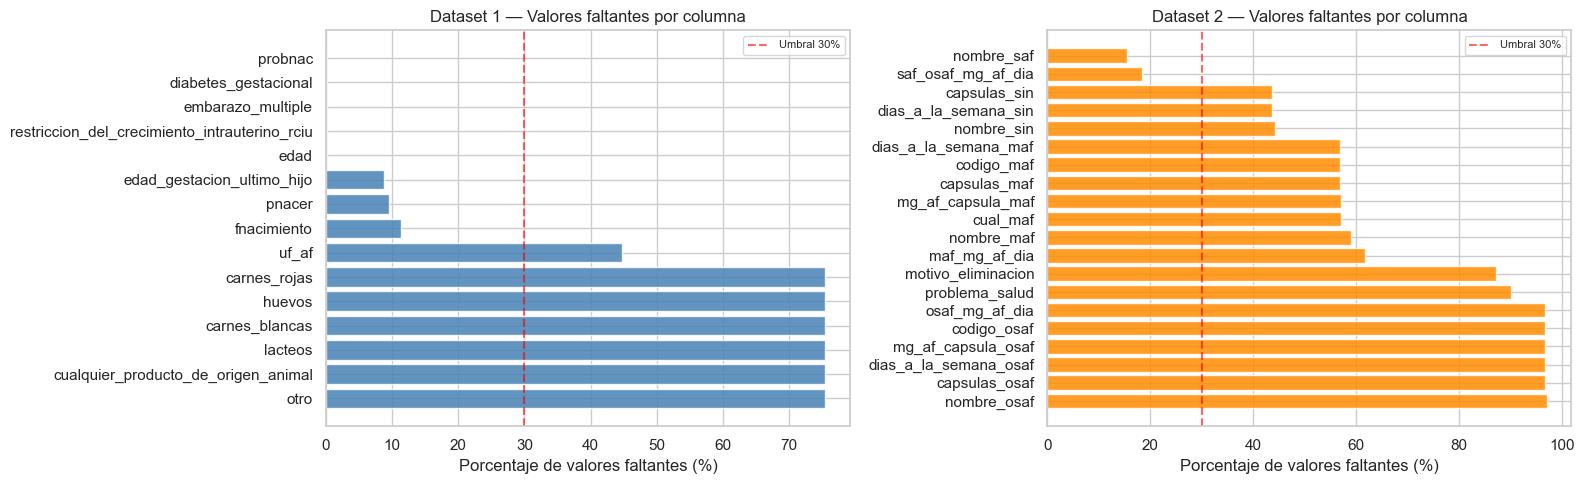

Figura guardada en outputs/


In [74]:
# Visualización: % de valores faltantes por columna
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, nulos_df, titulo, color in [
    (axes[0], nulos_d1, 'Dataset 1 — Valores faltantes por columna', 'steelblue'),
    (axes[1], nulos_d2, 'Dataset 2 — Valores faltantes por columna', 'darkorange'),
]:
    data = nulos_df.head(20)
    ax.barh(data.index, data['pct_nulos'], color=color, alpha=0.85)
    ax.set_xlabel('Porcentaje de valores faltantes (%)')
    ax.set_title(titulo)
    ax.axvline(x=30, color='red', linestyle='--', alpha=0.6, label='Umbral 30%')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'valores_faltantes.png'), bbox_inches='tight', dpi=100)
plt.show()
print('Figura guardada en outputs/')

### 9.2 Duplicados

In [75]:
for nombre, df in [('Dataset 1', df1), ('Dataset 2', df2)]:
    dup = df.duplicated().sum()
    print(f'{nombre}: {dup} filas duplicadas ({dup/len(df)*100:.2f}%)')
    if dup > 0:
        display(df[df.duplicated()].head(3))

Dataset 1: 0 filas duplicadas (0.00%)
Dataset 2: 0 filas duplicadas (0.00%)


### 9.3 Categorías y valores numéricos sospechosos

In [76]:
# Tablas de frecuencia de variables categóricas clave — Dataset 1
for col in ['sexo', 'neduc', 'region_chile', 'sitgest', 'paridad']:
    if col in df1.columns:
        print(f'\n[D1] {col}:')
        print(df1[col].value_counts(dropna=False).to_string())


[D1] sexo:
sexo
1    596
2    521
0     53

[D1] neduc:
neduc
6    453
4    312
5    234
7     98
3     56
2     13
1      4

[D1] region_chile:
region_chile
13    437
5     252
8     109
9      63
14     60
4      59
7      46
2      33
15     33
6      28
1      15
10     12
11      8
12      8
3       7

[D1] sitgest:
sitgest
0                     737
9                     153
5                     118
13                     49
4                      26
11                     19
14                     15
10                     13
6                       9
2                       4
7                       4
3                       4
15                      3
16                      3
17                      3
12                      3
8                       2
18                      2
reposo adsoluto         1
reposo por 5 meses      1
1                       1

[D1] paridad:
paridad
1          635
2          319
0           99
3           92
4           19
5 o más      6


In [29]:
# Tablas de frecuencia — Dataset 2
for col in ['sexo_rn_c', 'nivel_educacional_c', 'region_c', 'primipara_c', 'pandemia_c']:
    if col in df2.columns:
        print(f'\n[D2] {col}:')
        print(df2[col].value_counts(dropna=False).to_string())


[D2] sexo_rn_c:
sexo_rn_c
1.00      438
2.00      412
847.00      1
1.49        1
0.50        1

[D2] nivel_educacional_c:
nivel_educacional_c
4.00      516
5.00      206
3.00       75
2.00       49
1.00        4
847.00      1
4.03        1
0.77        1

[D2] region_c:
region_c
1.00      428
10.00      69
2.00       65
4.00       55
9.00       45
12.00      44
3.00       35
6.00       23
13.00      18
11.00      17
8.00       15
14.00       9
5.00        9
7.00        9
15.00       5
16.00       4
847.00      1
4.18        1
4.24        1

[D2] primipara_c:
primipara_c
1.00      462
0.00      388
847.00      1
0.54        1
0.50        1

[D2] pandemia_c:
pandemia_c
0.00      568
1.00      282
847.00      1
0.33        1
0.47        1


In [77]:
def revisar_rangos_numericos(df, nombre):
    print(f'\n=== Rangos numéricos — {nombre} ===')
    num_cols = df.select_dtypes(include='number').columns
    df_num = df[num_cols].apply(pd.to_numeric, errors='coerce')
    st = df_num.agg(['min', 'max', 'mean', 'median']).T
    st.columns = ['Mínimo', 'Máximo', 'Media', 'Mediana']
    display(st.round(2))

revisar_rangos_numericos(df1, 'Dataset 1')
revisar_rangos_numericos(df2, 'Dataset 2')


=== Rangos numéricos — Dataset 1 ===


,Mínimo,Máximo,Media,Mediana
cod,1.00,1170.00,585.50,585.50
edad,15.00,227.00,30.08,29.00
region_chile,1.00,15.00,9.27,9.00
neduc,1.00,7.00,5.15,5.00
sexo,0.00,2.00,1.40,1.00
preeclamsia,0.00,1.00,0.05,0.00
diabetes_gestacional,0.00,1.00,0.10,0.00
consumo_de_drogas_antes_o_durante_el_embarazo,0.00,1.00,0.03,0.00
exposicion_directa_o_indirecta_al_humo_del_cigarro,0.00,1.00,0.15,0.00
embarazo_multiple,0.00,1.00,0.02,0.00



=== Rangos numéricos — Dataset 2 ===


,Mínimo,Máximo,Media,Mediana
identificador_c,1.00,847.00,424.29,424.00
edad_madre,4.78,847.00,35.08,34.00
nacionalidad_c,0.18,847.00,2.03,1.00
region_c,1.00,847.00,5.17,1.00
nivel_educacional_c,0.77,847.00,5.01,4.00
numero_embarazo,0.86,847.00,2.65,1.00
primipara_c,0.00,847.00,1.54,1.00
sexo_rn_c,0.50,847.00,2.47,1.00
peso_rn_c,0.38,847.00,2.98,2.00
pandemia_c,0.00,847.00,1.32,0.00


## 10. Corrección y preparación de los datos

### 10.1 Correcciones en Dataset 1

In [78]:
n0 = len(df1)
df1 = df1.drop_duplicates().reset_index(drop=True)
print(f'Duplicados eliminados D1: {n0 - len(df1)}')

# Edad materna fuera de rango [15, 55]
if 'edad' in df1.columns:
    df1['edad'] = pd.to_numeric(df1['edad'], errors='coerce')
    mask = df1['edad'].notna() & ((df1['edad'] < 15) | (df1['edad'] > 55))
    print(f'Edad fuera de [15,55]: {mask.sum()} registros')
    if mask.sum() > 0:
        display(df1.loc[mask, ['cod', 'edad']])
        df1.loc[mask, 'edad'] = np.nan
        print('  → Convertidos a NaN')

# Peso al nacer fuera de rango [400, 6000] g
if 'pnacer' in df1.columns:
    df1['pnacer'] = pd.to_numeric(df1['pnacer'], errors='coerce')
    mask = df1['pnacer'].notna() & ((df1['pnacer'] < 400) | (df1['pnacer'] > 6000))
    print(f'Peso nacer fuera de [400,6000] g: {mask.sum()} registros')
    if mask.sum() > 0:
        display(df1.loc[mask, ['cod', 'pnacer']])
        df1.loc[mask, 'pnacer'] = np.nan
        print('  → Convertidos a NaN')

# Edad gestacional fuera de rango [24, 44] semanas
eg_col = 'edad_gestacion_ultimo_hijo'
if eg_col in df1.columns:
    df1[eg_col] = pd.to_numeric(df1[eg_col], errors='coerce')
    mask = df1[eg_col].notna() & ((df1[eg_col] < 24) | (df1[eg_col] > 44))
    print(f'EG fuera de [24,44] sem: {mask.sum()} registros')
    if mask.sum() > 0:
        display(df1.loc[mask, ['cod', eg_col]])
        df1.loc[mask, eg_col] = np.nan
        print('  → Convertidos a NaN')

# Limpieza de categorías codificadas inválidas
# Sexo válido: 1,2
if 'sexo' in df1.columns:
    s = pd.to_numeric(df1['sexo'], errors='coerce')
    mask = s.notna() & ~s.isin([1, 2])
    print(f'Sexo inválido (distinto de 1/2): {mask.sum()} registros')
    if mask.sum() > 0:
        display(df1.loc[mask, ['cod', 'sexo']])
        df1.loc[mask, 'sexo'] = np.nan
        print('  → Convertidos a NaN')

# Nivel educacional esperado 1..7
if 'neduc' in df1.columns:
    s = pd.to_numeric(df1['neduc'], errors='coerce')
    mask = s.notna() & ~s.isin([1, 2, 3, 4, 5, 6, 7])
    print(f'Nivel educacional inválido: {mask.sum()} registros')
    if mask.sum() > 0:
        display(df1.loc[mask, ['cod', 'neduc']])
        df1.loc[mask, 'neduc'] = np.nan
        print('  → Convertidos a NaN')

# Región Chile: si esperas códigos 1..16, ajusta si aplica
if 'region_chile' in df1.columns:
    s = pd.to_numeric(df1['region_chile'], errors='coerce')
    mask = s.notna() & ~s.isin(list(range(1, 17)))
    print(f'Región inválida: {mask.sum()} registros')
    if mask.sum() > 0:
        display(df1.loc[mask, ['cod', 'region_chile']])
        df1.loc[mask, 'region_chile'] = np.nan
        print('  → Convertidos a NaN')

print('Correcciones Dataset 1 completadas.')

Duplicados eliminados D1: 0
Edad fuera de [15,55]: 2 registros


,cod,edad
78,79,85.00
83,84,227.00


  → Convertidos a NaN
Peso nacer fuera de [400,6000] g: 1 registros


,cod,pnacer
986,987,179.00


  → Convertidos a NaN
EG fuera de [24,44] sem: 2 registros


,cod,edad_gestacion_ultimo_hijo
585,586,0.00
1095,1096,0.00


  → Convertidos a NaN
Sexo inválido (distinto de 1/2): 53 registros


,cod,sexo
4,5,0
12,13,0
39,40,0
42,43,0
55,56,0
71,72,0
110,111,0
118,119,0
190,191,0
202,203,0


  → Convertidos a NaN
Nivel educacional inválido: 0 registros
Región inválida: 0 registros
Correcciones Dataset 1 completadas.


### 10.2 Correcciones en Dataset 2

In [79]:
n0 = len(df2)
df2 = df2.drop_duplicates().reset_index(drop=True)
print(f'Duplicados eliminados D2: {n0 - len(df2)}')

cols_num_d2 = [
    'edad_madre', 'peso_rn', 'imc_pregestacional',
    'talla_materna', 'eg_rn', 'delta_peso_gestacional',
    'delta_imc', 'numero_embarazo',
    'nacionalidad_c', 'region_c', 'nivel_educacional_c',
    'primipara_c', 'sexo_rn_c', 'peso_rn_c', 'pandemia_c',
    'eg_rn_c', 'delta_peso_gestacional_c', 'imc_pregestacional_c',
    'imc_termino_c', 'condicion_materna_c', 'problema_salud_rn_c',
    'problema_salud_c', 'consumo_saf', 'consumo_osaf',
    'consumo_maf', 'consumo_pan_c', 'consumo_pastas_con_af'
]

for col in cols_num_d2:
    if col in df2.columns:
        df2[col] = pd.to_numeric(df2[col], errors='coerce')

sentinelas = {800, 843, 845, 847}

cols_codificadas_d2 = [
    'nacionalidad_c', 'region_c', 'nivel_educacional_c', 'primipara_c',
    'sexo_rn_c', 'peso_rn_c', 'pandemia_c', 'eg_rn_c',
    'delta_peso_gestacional_c', 'imc_pregestacional_c', 'imc_termino_c',
    'condicion_materna_c', 'problema_salud_rn_c', 'problema_salud_c',
    'consumo_saf', 'consumo_osaf', 'consumo_maf', 'consumo_pan_c',
    'consumo_pastas_con_af'
]

for col in cols_codificadas_d2:
    if col in df2.columns:
        mask = df2[col].notna() & df2[col].isin(sentinelas)
        if mask.sum() > 0:
            print(f'{col}: sentinelas específicos detectados: {mask.sum()}')
            df2.loc[mask, col] = np.nan

if 'edad_madre' in df2.columns:
    mask = df2['edad_madre'].notna() & ((df2['edad_madre'] < 15) | (df2['edad_madre'] > 55))
    print(f'Edad madre fuera de [15,55]: {mask.sum()}')
    if mask.sum() > 0:
        display(df2.loc[mask, ['edad_madre']])
        df2.loc[mask, 'edad_madre'] = np.nan

if 'peso_rn' in df2.columns:
    mask = df2['peso_rn'].notna() & ((df2['peso_rn'] < 400) | (df2['peso_rn'] > 6000))
    print(f'Peso RN fuera de [400,6000] g: {mask.sum()}')
    if mask.sum() > 0:
        display(df2.loc[mask, ['peso_rn']])
        df2.loc[mask, 'peso_rn'] = np.nan

if 'imc_pregestacional' in df2.columns:
    mask = df2['imc_pregestacional'].notna() & ((df2['imc_pregestacional'] < 14) | (df2['imc_pregestacional'] > 60))
    print(f'IMC fuera de [14,60]: {mask.sum()}')
    if mask.sum() > 0:
        display(df2.loc[mask, ['imc_pregestacional']])
        df2.loc[mask, 'imc_pregestacional'] = np.nan

if 'talla_materna' in df2.columns:
    mask = df2['talla_materna'].notna() & ((df2['talla_materna'] < 120) | (df2['talla_materna'] > 220))
    print(f'Talla materna fuera de [120,220]: {mask.sum()}')
    if mask.sum() > 0:
        display(df2.loc[mask, ['talla_materna']])
        df2.loc[mask, 'talla_materna'] = np.nan

if 'eg_rn' in df2.columns:
    mask = df2['eg_rn'].notna() & ((df2['eg_rn'] < 24) | (df2['eg_rn'] > 44))
    print(f'EG RN fuera de [24,44]: {mask.sum()}')
    if mask.sum() > 0:
        display(df2.loc[mask, ['eg_rn']])
        df2.loc[mask, 'eg_rn'] = np.nan

if 'delta_peso_gestacional' in df2.columns:
    mask = df2['delta_peso_gestacional'].notna() & ((df2['delta_peso_gestacional'] < -30) | (df2['delta_peso_gestacional'] > 50))
    print(f'Delta peso gestacional fuera de [-30,50]: {mask.sum()}')
    if mask.sum() > 0:
        display(df2.loc[mask, ['delta_peso_gestacional']])
        df2.loc[mask, 'delta_peso_gestacional'] = np.nan

valid_sexo  = {1.0, 2.0}
valid_bin   = {0.0, 1.0}
valid_neduc = {1.0, 2.0, 3.0, 4.0, 5.0}

for col, validos in [
    ('sexo_rn_c',           valid_sexo),
    ('primipara_c',         valid_bin),
    ('pandemia_c',          valid_bin),
    ('nivel_educacional_c', valid_neduc),
]:
    if col in df2.columns:
        s = pd.to_numeric(df2[col], errors='coerce')
        mask = s.notna() & ~s.isin(validos)
        print(f'{col} inválidos: {mask.sum()}')
        if mask.sum() > 0:
            display(df2.loc[mask, [col]])
            df2.loc[mask, col] = np.nan

print(f'\nTotal registros Dataset 2 tras limpieza: {len(df2)}')
print('\nCorrecciones Dataset 2 completadas.')

Duplicados eliminados D2: 0
nacionalidad_c: sentinelas específicos detectados: 1
region_c: sentinelas específicos detectados: 1
nivel_educacional_c: sentinelas específicos detectados: 1
primipara_c: sentinelas específicos detectados: 1
sexo_rn_c: sentinelas específicos detectados: 1
peso_rn_c: sentinelas específicos detectados: 1
pandemia_c: sentinelas específicos detectados: 1
imc_pregestacional_c: sentinelas específicos detectados: 1
imc_termino_c: sentinelas específicos detectados: 1
condicion_materna_c: sentinelas específicos detectados: 1
problema_salud_rn_c: sentinelas específicos detectados: 1
problema_salud_c: sentinelas específicos detectados: 1
consumo_saf: sentinelas específicos detectados: 1
consumo_osaf: sentinelas específicos detectados: 1
consumo_maf: sentinelas específicos detectados: 1
consumo_pan_c: sentinelas específicos detectados: 1
consumo_pastas_con_af: sentinelas específicos detectados: 1
Edad madre fuera de [15,55]: 2


,edad_madre
847,847.00
852,4.78


Peso RN fuera de [400,6000] g: 0
IMC fuera de [14,60]: 5


,imc_pregestacional
578,222.22
801,60.23
847,845.00
849,222.22
852,8.57


Talla materna fuera de [120,220]: 4


...

pandemia_c inválidos: 2


,pandemia_c
850,0.33
852,0.47


nivel_educacional_c inválidos: 2


,nivel_educacional_c
850,4.03
852,0.77



Total registros Dataset 2 tras limpieza: 853

Correcciones Dataset 2 completadas.


### 10.3 Variables derivadas

In [80]:
# Dataset 1: indicador binario de consumo de suplemento AF
col_consumo_d1 = 'consumio_suplementos_de_acido_folico_o_vitaminas_durante_su_embarazo'
if col_consumo_d1 in df1.columns:
    s = pd.to_numeric(df1[col_consumo_d1], errors='coerce')
    df1['consumio_saf_binario'] = np.where(s.isna(), np.nan, np.where(s == 1, 1, 0))
    print('Variable derivada: consumio_saf_binario (desde variable original)')
    print(df1['consumio_saf_binario'].value_counts(dropna=False))
elif 'uf_af' in df1.columns:
    uf = pd.to_numeric(df1['uf_af'], errors='coerce')
    df1['consumio_saf_binario'] = np.where(uf.isna(), np.nan, np.where(uf > 0, 1, 0))
    print('Variable derivada: consumio_saf_binario (desde uf_af)')
    print(df1['consumio_saf_binario'].value_counts(dropna=False))

# Dataset 1: categoría de peso al nacer
if 'pnacer' in df1.columns:
    df1['pnacer'] = pd.to_numeric(df1['pnacer'], errors='coerce')
    bins   = [0, 1500, 2500, 4000, 9999]
    labels = [
        'Muy bajo (<1500g)',
        'Bajo peso (1500-2499g)',
        'Normal (2500-3999g)',
        'Macrosomia (>=4000g)'
    ]
    df1['categoria_pnacer'] = pd.cut(df1['pnacer'], bins=bins, labels=labels, right=False)
    print('\nVariable derivada: categoria_pnacer')
    print(df1['categoria_pnacer'].value_counts(dropna=False))

Variable derivada: consumio_saf_binario (desde variable original)
consumio_saf_binario
1.00    1008
0.00     162
Name: count, dtype: int64

Variable derivada: categoria_pnacer
categoria_pnacer
Normal (2500-3999g)       916
NaN                       115
Macrosomia (>=4000g)       86
Bajo peso (1500-2499g)     44
Muy bajo (<1500g)           9
Name: count, dtype: int64


In [81]:
# Dataset 2: IMC pregestacional categorizado
if 'imc_pregestacional' in df2.columns:
    df2['imc_pregestacional'] = pd.to_numeric(df2['imc_pregestacional'], errors='coerce')

    bins_imc   = [0, 18.5, 25, 30, 100]
    labels_imc = [
        'Bajo peso (<18.5)',
        'Normal (18.5-24.9)',
        'Sobrepeso (25-29.9)',
        'Obesidad (≥30)'
    ]

    df2['categoria_imc_pregestacional'] = pd.cut(
        df2['imc_pregestacional'],
        bins=bins_imc,
        labels=labels_imc,
        right=False
    )

    print('\nVariable derivada: categoria_imc_pregestacional')
    print(df2['categoria_imc_pregestacional'].value_counts(dropna=False))

# Dataset 2: etiqueta texto pandemia
if 'pandemia_c' in df2.columns:
    df2['pandemia_c'] = pd.to_numeric(df2['pandemia_c'], errors='coerce')

    df2['pandemia_label'] = df2['pandemia_c'].map({
        0: 'Pre-pandemia',
        1: 'Pandemia',
        0.0: 'Pre-pandemia',
        1.0: 'Pandemia'
    })

    print('\nVariable derivada: pandemia_label')
    print(df2['pandemia_label'].value_counts(dropna=False))


Variable derivada: categoria_imc_pregestacional
categoria_imc_pregestacional
Normal (18.5-24.9)     360
Sobrepeso (25-29.9)    288
Obesidad (≥30)         187
Bajo peso (<18.5)       11
NaN                      7
Name: count, dtype: int64

Variable derivada: pandemia_label
pandemia_label
Pre-pandemia    568
Pandemia        282
NaN               3
Name: count, dtype: int64


## 11. Clasificación de variables para el análisis

Clasificamos automáticamente las variables en tipos: numérica, categórica, ordinal, fecha y texto.

In [82]:
def clasificar_variables(df, ajustes_manuales=None):
    """
    Clasifica variables en:
    numerica, categorica, ordinal, fecha, texto.
    """
    clases = {'numerica': [], 'categorica': [], 'ordinal': [], 'fecha': [], 'texto': []}

    for col in df.columns:
        if ajustes_manuales and col in ajustes_manuales:
            clases[ajustes_manuales[col]].append(col)
            continue

        dtype = df[col].dtype
        nombre = col.lower()
        nu = df[col].nunique(dropna=True)

        if pd.api.types.is_datetime64_any_dtype(dtype):
            clases['fecha'].append(col)

        elif pd.api.types.is_numeric_dtype(dtype):
            # binarias
            if nu <= 2:
                clases['categorica'].append(col)

            # variables claramente codificadas por nombre
            elif any(k in nombre for k in [
                'region', 'sexo', 'nivel', 'nacionalidad', 'primipara',
                'pandemia', 'consumo_', '_c', 'categoria_', 'label'
            ]):
                clases['ordinal'].append(col)

            # ordinales por pocos niveles
            elif nu <= 10:
                clases['ordinal'].append(col)

            else:
                clases['numerica'].append(col)

        else:
            clases['categorica' if nu <= 30 else 'texto'].append(col)

    return clases

ajustes_d1 = {
    'cod': 'texto',
    'region_chile': 'categorica',
    'neduc': 'ordinal',
    'sexo': 'categorica',
    'sitgest': 'categorica',
    'fnacimiento': 'fecha',
    'consumio_saf_binario': 'categorica',
    'categoria_pnacer': 'ordinal',
    'paridad': 'ordinal',
    'pnacer': 'numerica',
    'edad_gestacion_ultimo_hijo': 'numerica',
    'uf_af': 'numerica',
    'probnac': 'categorica',
    'no_consumio': 'categorica',
    'no_consumi_suplemento_en_ningun_periodo': 'categorica',
    'no_deje_de_comer_ninguno': 'categorica',
    'no_como_pan': 'categorica',
}

ajustes_d2 = {
    'identificador_c': 'texto',
    'region_c': 'categorica',
    'nivel_educacional_c': 'ordinal',
    'sexo_rn_c': 'categorica',
    'primipara_c': 'categorica',
    'pandemia_c': 'categorica',
    'nacimiento_madre': 'fecha',
    'nacimiento_rn': 'fecha',
    'marca_temporal': 'fecha',
    'categoria_imc_pregestacional': 'ordinal',
    'pandemia_label': 'categorica',
    'motivo_eliminacion': 'categorica',
    'peso_rn': 'numerica',
    'peso_pregestacional': 'numerica',
    'peso_postparto': 'numerica',
    'imc_pregestacional': 'numerica',
    'imc_postparto': 'numerica',
    'eg_rn': 'numerica',
    'numero_embarazo': 'ordinal',
    'problema_salud': 'texto',
    'problema_salud_rn_c': 'categorica',
    'problema_salud_c': 'ordinal',
}

 en estudios observacionales: imputacion conservadora en variables numericas con faltante bajo (<=20%), indicadores de faltante y reporte explicito de categorias sin dato.

In [83]:
def preparar_datos_para_analisis(df, clases, nombre, umbral_imputacion_num=20, reglas_nulos=None):
    """
    Manejo conservador de faltantes:
    - numéricas: imputación con mediana solo si faltante <= umbral y no son nulos semánticos
    - categóricas/texto: se conserva NaN si el faltante es semántico o si es categoría codificada numérica
    - se agrega indicador de faltante en numéricas imputadas
    """
    if reglas_nulos is None:
        reglas_nulos = {}

    df_out = df.copy()
    filas = []

    cols_num = [c for c in clases.get('numerica', []) if c in df_out.columns]
    cols_cat = [c for c in (
        clases.get('categorica', []) +
        clases.get('ordinal', []) +
        clases.get('texto', [])
    ) if c in df_out.columns]


    # NUMÉRICAS

    for col in cols_num:
        s = pd.to_numeric(df_out[col], errors='coerce')
        n_nulos = int(s.isna().sum())

        if n_nulos == 0:
            df_out[col] = s
            continue

        pct = n_nulos / len(df_out) * 100
        regla_nulo = reglas_nulos.get(col, 'faltante_real_o_por_confirmar')

        # no imputar si es no_aplica semántico
        if str(regla_nulo).startswith('no_aplica'):
            df_out[col] = s
            accion = 'Se mantiene NaN (faltante semántico: no aplica)'

        elif pct <= umbral_imputacion_num:
            mediana = float(s.median())
            df_out[f'{col}_faltante'] = s.isna().astype('int8')
            df_out[col] = s.fillna(mediana)
            accion = f'Imputación mediana ({mediana:.2f}) + indicador'

        else:
            df_out[col] = s
            accion = f'Sin imputar (>{umbral_imputacion_num}% faltante)'

        filas.append({
            'variable': col,
            'tipo': 'numerica',
            'n_nulos': n_nulos,
            'pct_nulos': round(pct, 1),
            'significado_nulos': regla_nulo,
            'accion': accion,
        })


    # CATEGÓRICAS / ORDINALES / TEXTO

    for col in cols_cat:
        s = df_out[col]
        n_nulos = int(s.isna().sum())

        if n_nulos == 0:
            continue

        pct = n_nulos / len(df_out) * 100
        regla_nulo = reglas_nulos.get(col, 'faltante_real_o_por_confirmar')

        # Si es nulo semántico, no se toca
        if str(regla_nulo).startswith('no_aplica'):
            accion = 'Se mantiene NaN (faltante semántico: no aplica)'

        # Si es categórica codificada numérica, mejor mantener NaN
        elif pd.api.types.is_numeric_dtype(s):
            accion = 'Se mantiene NaN (categoría codificada numérica)'

        # Solo texto/categoría no numérica -> "No reportado"
        else:
            df_out[col] = s.astype(object).where(s.notna(), 'No reportado')
            accion = "Relleno con 'No reportado'"

        filas.append({
            'variable': col,
            'tipo': 'categorica',
            'n_nulos': n_nulos,
            'pct_nulos': round(pct, 1),
            'significado_nulos': regla_nulo,
            'accion': accion,
        })

    rep = pd.DataFrame(filas)
    if not rep.empty:
        rep = rep.sort_values(['pct_nulos', 'variable'], ascending=[False, True]).reset_index(drop=True)

    print(f'\nEstrategia de faltantes aplicada - {nombre}')
    print(f'Columnas con acciones: {len(rep)}')
    if not rep.empty:
        display(rep.head(30))

    return df_out, rep

In [84]:
clases_d1 = clasificar_variables(df1, ajustes_d1)
clases_d2 = clasificar_variables(df2, ajustes_d2)

df1_analisis, rep_faltantes_d1 = preparar_datos_para_analisis(
    df1,
    clases_d1,
    'Dataset 1 - Ingesta AF',
    reglas_nulos=REGLAS_NULOS_D1
)

df2_analisis, rep_faltantes_d2 = preparar_datos_para_analisis(
    df2,
    clases_d2,
    'Dataset 2 - Encuesta AF',
    reglas_nulos=REGLAS_NULOS_D2
)

rep_faltantes_d1.to_csv(
    os.path.join(PROC_DIR, 'reporte_manejo_faltantes_d1.csv'),
    index=False,
    encoding='utf-8-sig'
)
rep_faltantes_d2.to_csv(
    os.path.join(PROC_DIR, 'reporte_manejo_faltantes_d2.csv'),
    index=False,
    encoding='utf-8-sig'
)

# A partir de aquí, el análisis usa las copias tratadas
df1 = df1_analisis.copy()
df2 = df2_analisis.copy()

print('\nDataframes activos para análisis:')
print(f'  Dataset 1: {df1.shape}')
print(f'  Dataset 2: {df2.shape}')


Estrategia de faltantes aplicada - Dataset 1 - Ingesta AF
Columnas con acciones: 16


,variable,tipo,n_nulos,pct_nulos,significado_nulos,accion
0,otro,categorica,883,75.50,no_aplica_si_no_restriccion,Se mantiene NaN (faltante semántico: no aplica)
1,carnes_blancas,categorica,882,75.40,no_aplica_si_no_restriccion,Se mantiene NaN (faltante semántico: no aplica)
2,carnes_rojas,categorica,882,75.40,no_aplica_si_no_restriccion,Se mantiene NaN (faltante semántico: no aplica)
3,cualquier_producto_de_origen_animal,categorica,882,75.40,no_aplica_si_no_restriccion,Se mantiene NaN (faltante semántico: no aplica)
4,huevos,categorica,882,75.40,no_aplica_si_no_restriccion,Se mantiene NaN (faltante semántico: no aplica)
5,lacteos,categorica,882,75.40,no_aplica_si_no_restriccion,Se mantiene NaN (faltante semántico: no aplica)
6,uf_af,numerica,523,44.70,faltante_real_o_por_confirmar,Sin imputar (>20% faltante)
7,edad_gestacion_ultimo_hijo,numerica,120,10.30,faltante_real_o_por_confirmar,Imputación mediana (39.00) + indicador
8,categoria_pnacer,categorica,115,9.80,faltante_real_o_por_confirmar,Relleno con 'No reportado'
9,pnacer,numerica,115,9.80,faltante_real_o_por_confirmar,Imputación mediana (3390.00) + indicador



Estrategia de faltantes aplicada - Dataset 2 - Encuesta AF
Columnas con acciones: 73


,variable,tipo,n_nulos,pct_nulos,significado_nulos,accion
0,nombre_osaf,categorica,827,97.00,no_aplica_si_no_consumo_osaf,Se mantiene NaN (faltante semántico: no aplica)
1,capsulas_osaf,categorica,825,96.70,no_aplica_si_no_consumo_osaf,Se mantiene NaN (faltante semántico: no aplica)
2,codigo_osaf,categorica,825,96.70,no_aplica_si_no_consumo_osaf,Se mantiene NaN (faltante semántico: no aplica)
3,dias_a_la_semana_osaf,categorica,825,96.70,no_aplica_si_no_consumo_osaf,Se mantiene NaN (faltante semántico: no aplica)
4,mg_af_capsula_osaf,categorica,825,96.70,no_aplica_si_no_consumo_osaf,Se mantiene NaN (faltante semántico: no aplica)
5,osaf_mg_af_dia,numerica,825,96.70,no_aplica_si_no_consumo_osaf,Se mantiene NaN (faltante semántico: no aplica)
6,problema_salud,categorica,768,90.00,no_aplica_si_no_problema_salud_rn,Se mantiene NaN (faltante semántico: no aplica)
7,motivo_eliminacion,categorica,743,87.10,faltante_real_o_por_confirmar,Relleno con 'No reportado'
8,maf_mg_af_dia,numerica,526,61.70,no_aplica_si_no_consumo_maf,Se mantiene NaN (faltante semántico: no aplica)
9,nombre_maf,categorica,504,59.10,no_aplica_si_no_consumo_maf,Se mantiene NaN (faltante semántico: no aplica)



Dataframes activos para análisis:
  Dataset 1: (1170, 69)
  Dataset 2: (853, 100)


## 12. Análisis descriptivo de variables cuantitativas

Calculamos estadísticas descriptivas completas para las variables numéricas más relevantes.

In [85]:
def estadisticas_cuantitativas(df, cols_num):
    """Estadísticas descriptivas extendidas para variables numéricas analíticas."""
    filas = []

    for col in cols_num:
        s_raw = pd.to_numeric(df[col], errors='coerce')
        n_total = len(s_raw)
        n_nulos = int(s_raw.isna().sum())
        pct_nulos = round(n_nulos / n_total * 100, 1)

        s = s_raw.dropna()

        if len(s) < 2:
            continue

        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        outliers = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

        moda = s.mode().iloc[0] if len(s.mode()) > 0 else np.nan

        filas.append({
            'Variable'      : col,
            'N válidos'     : len(s),
            'N nulos'       : n_nulos,
            '% nulos'       : pct_nulos,
            'Media'         : round(s.mean(), 2),
            'Mediana'       : round(s.median(), 2),
            'Moda'          : round(moda, 2) if pd.notna(moda) else np.nan,
            'Mínimo'        : round(s.min(), 2),
            'Máximo'        : round(s.max(), 2),
            'Rango'         : round(s.max() - s.min(), 2),
            'Varianza'      : round(s.var(), 2),
            'Desv. Est.'    : round(s.std(), 2),
            'Q1'            : round(q1, 2),
            'Q2'            : round(s.median(), 2),
            'Q3'            : round(q3, 2),
            'IQR'           : round(iqr, 2),
            'Asimetría'     : round(s.skew(), 2),
            'Curtosis'      : round(s.kurt(), 2),
            'Outliers'      : outliers,
        })

    return pd.DataFrame(filas).set_index('Variable')

def filtrar_numericas_analiticas(cols):
    excluir_patrones = ['_faltante', '_no_aplica', 'identificador', 'cod']
    return [
        c for c in cols
        if not any(p in c.lower() for p in excluir_patrones)
    ]

In [86]:
num_d1 = filtrar_numericas_analiticas(
    [c for c in clases_d1['numerica'] if c in df1.columns]
)
stats_d1 = estadisticas_cuantitativas(df1, num_d1)
print('Estadísticas descriptivas — Dataset 1:')
display(stats_d1)

num_d2 = filtrar_numericas_analiticas(
    [c for c in clases_d2['numerica'] if c in df2.columns]
)
stats_d2 = estadisticas_cuantitativas(df2, num_d2)
print('Estadísticas descriptivas — Dataset 2:')
display(stats_d2)

Estadísticas descriptivas — Dataset 1:


,N válidos,N nulos,% nulos,Media,Mediana,Moda,Mínimo,Máximo,Rango,Varianza,Desv. Est.,Q1,Q2,Q3,IQR,Asimetría,Curtosis,Outliers
Variable,,,,,,,,,,,,,,,,,,
edad,1170,0,0.00,29.86,29.00,26.00,15.00,55.00,40.00,37.99,6.16,26.00,29.00,34.00,8.00,0.29,-0.04,4
pnacer,1170,0,0.00,3354.95,3390.00,3390.00,800.00,5450.00,4650.00,257891.42,507.83,3111.25,3390.00,3620.00,508.75,-0.68,3.50,52
edad_gestacion_ultimo_hijo,1170,0,0.00,38.64,39.00,39.00,33.00,42.00,9.00,2.01,1.42,38.00,39.00,39.00,1.00,-0.61,1.49,168
uf_af,647,523,44.70,2728.75,1000.00,1000.00,200.00,5000.00,4800.00,3670936.98,1915.97,1000.00,1000.00,5000.00,4000.00,0.28,-1.84,0


Estadísticas descriptivas — Dataset 2:


,N válidos,N nulos,% nulos,Media,Mediana,Moda,Mínimo,Máximo,Rango,Varianza,Desv. Est.,Q1,Q2,Q3,IQR,Asimetría,Curtosis,Outliers
Variable,,,,,,,,,,,,,,,,,,
edad_madre,853,0,0.00,34.16,34.00,33.00,21.00,49.00,28.00,23.17,4.81,31.00,34.00,37.00,6.00,-0.10,-0.15,7
peso_rn,853,0,0.00,3282.39,3322.00,3250.00,527.10,4910.00,4382.90,300330.47,548.02,3010.00,3322.00,3610.00,600.00,-0.75,2.25,40
eg_rn,853,0,0.00,38.36,38.57,38.00,28.00,42.14,14.14,2.89,1.70,38.00,38.57,39.14,1.14,-1.63,5.89,120
peso_pregestacional,853,0,0.00,70.25,67.00,80.00,14.71,845.00,830.29,936.37,30.60,59.00,67.00,78.00,19.00,19.23,483.16,21
talla_materna,853,0,0.00,160.97,160.00,160.00,144.00,184.00,40.00,37.53,6.13,157.00,160.00,165.00,8.00,0.25,0.12,5
peso_postparto,853,0,0.00,80.10,79.00,80.00,14.30,843.00,828.70,898.59,29.98,69.00,79.00,87.00,18.00,19.46,493.15,23
delta_peso_gestacional,853,0,0.00,9.91,10.00,10.00,-22.00,37.00,59.00,42.65,6.53,7.00,10.00,13.00,6.00,-0.29,3.13,57
imc_pregestacional,853,0,0.00,26.66,25.53,25.53,16.41,48.89,32.49,26.79,5.18,23.05,25.53,29.48,6.42,1.00,1.25,25
imc_postparto,853,0,0.00,31.49,30.06,31.25,5.06,843.00,837.94,800.73,28.30,26.91,30.06,33.23,6.31,27.75,796.50,23


In [87]:
stats_d1.to_csv(
    os.path.join(PROC_DIR, 'estadisticas_numericas_dataset1.csv'),
    encoding='utf-8-sig'
)
stats_d2.to_csv(
    os.path.join(PROC_DIR, 'estadisticas_numericas_dataset2.csv'),
    encoding='utf-8-sig'
)
print('Estadísticas guardadas.')

Estadísticas guardadas.


### 12.1 Boxplots — Dataset 1

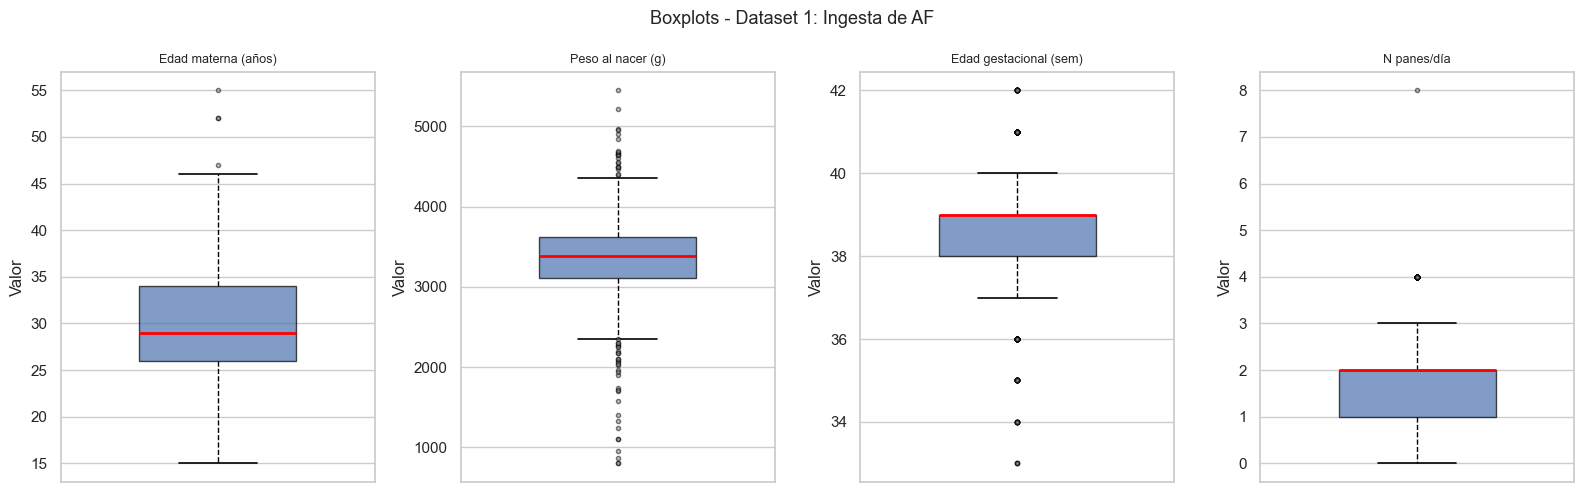

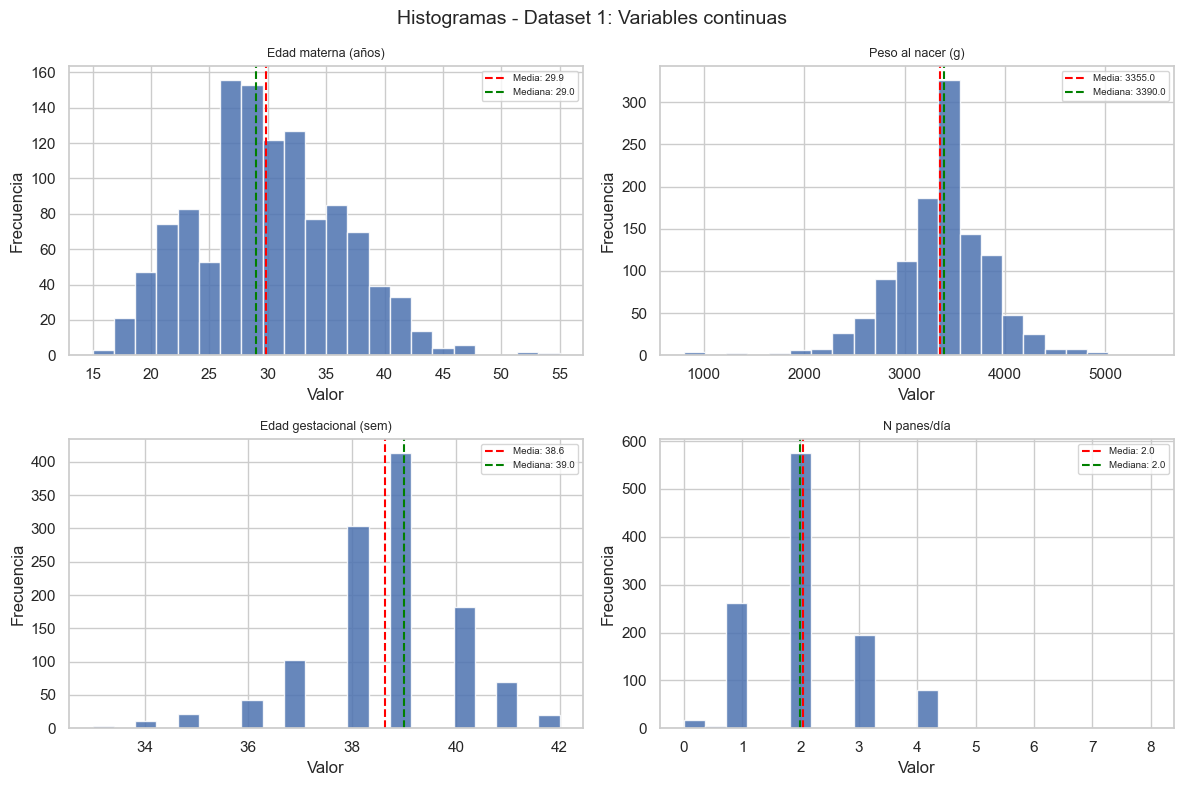

In [88]:
vars_box_d1 = ['edad', 'pnacer', 'edad_gestacion_ultimo_hijo', 'n_panes']
vars_box_d1 = [v for v in vars_box_d1 if v in df1.columns and pd.to_numeric(df1[v], errors='coerce').notna().sum() > 5]

etiq_d1 = {
    'edad': 'Edad materna (años)',
    'pnacer': 'Peso al nacer (g)',
    'edad_gestacion_ultimo_hijo': 'Edad gestacional (sem)',
    'n_panes': 'N panes/día',
}

if len(vars_box_d1) == 0:
    print('No hay variables válidas para boxplots en Dataset 1')
else:
    n = len(vars_box_d1)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, vars_box_d1):
        data = pd.to_numeric(df1[col], errors='coerce').dropna()

        ax.boxplot(
            data,
            patch_artist=True,
            widths=0.5,
            boxprops=dict(facecolor='#4C72B0', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(linestyle='--'),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5)
        )
        ax.set_title(etiq_d1.get(col, col), fontsize=9)
        ax.set_ylabel('Valor')
        ax.set_xticks([])

    fig.suptitle('Boxplots - Dataset 1: Ingesta de AF', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'boxplots_dataset1.png'), bbox_inches='tight', dpi=100)
    plt.show()


vars_hist_d1 = ['edad', 'pnacer', 'edad_gestacion_ultimo_hijo', 'n_panes']
vars_hist_d1 = [v for v in vars_hist_d1 if v in df1.columns and pd.to_numeric(df1[v], errors='coerce').notna().sum() > 5]

titulos_hist_d1 = {
    'edad': 'Edad materna (años)',
    'pnacer': 'Peso al nacer (g)',
    'edad_gestacion_ultimo_hijo': 'Edad gestacional (sem)',
    'n_panes': 'N panes/día',
}

if len(vars_hist_d1) == 0:
    print('No hay variables válidas para histogramas en Dataset 1')
else:
    nc = 2
    nr = (len(vars_hist_d1) + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(6*nc, 4*nr))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(vars_hist_d1):
        data = pd.to_numeric(df1[col], errors='coerce').dropna()

        axes[i].hist(data, bins=22, color='#4C72B0', edgecolor='white', alpha=0.85)
        axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'Media: {data.mean():.1f}')
        axes[i].axvline(data.median(), color='green', linestyle='--', label=f'Mediana: {data.median():.1f}')
        axes[i].set_title(titulos_hist_d1.get(col, col), fontsize=9)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend(fontsize=7)

    for j in range(len(vars_hist_d1), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Histogramas - Dataset 1: Variables continuas', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'histogramas_dataset1.png'), bbox_inches='tight', dpi=100)
    plt.show()

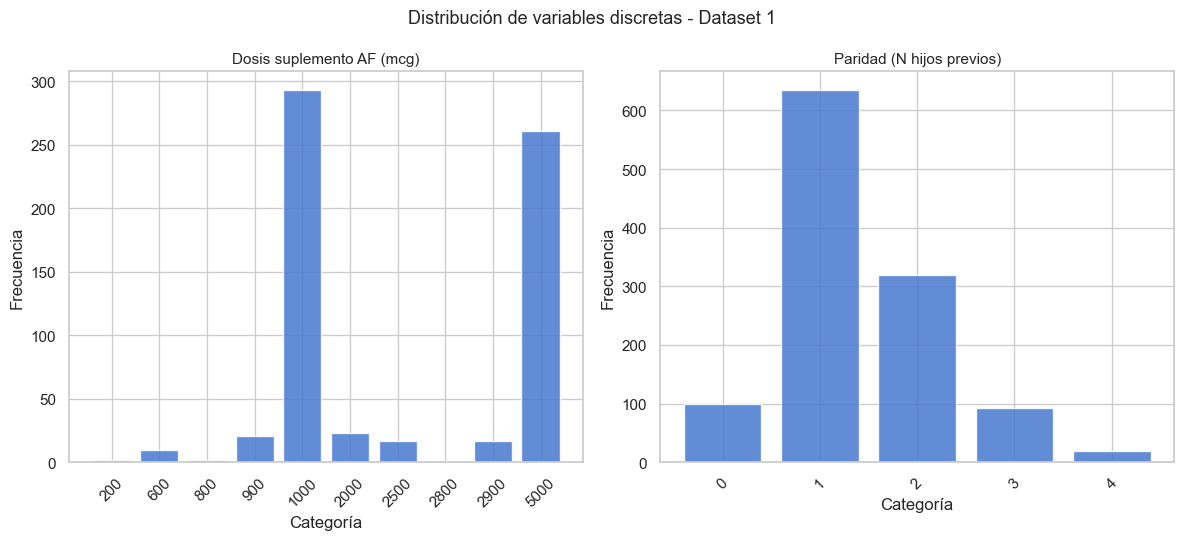

In [89]:
discretas_d1 = []
for col, titulo in [('uf_af', 'Dosis suplemento AF (mcg)'), ('paridad', 'Paridad (N hijos previos)')]:
    if col in df1.columns and pd.to_numeric(df1[col], errors='coerce').notna().sum() > 5:
        discretas_d1.append((col, titulo))

if len(discretas_d1) == 0:
    print('No hay variables discretas válidas para Dataset 1')
else:
    fig2, axes2 = plt.subplots(1, len(discretas_d1), figsize=(6*len(discretas_d1), 5.5))
    if len(discretas_d1) == 1:
        axes2 = [axes2]

    for ax, (col, titulo) in zip(axes2, discretas_d1):
        s = pd.to_numeric(df1[col], errors='coerce').dropna()
        freq = s.value_counts().sort_index()

        labels = [str(int(v)) if v == int(v) else str(round(v, 1)) for v in freq.index]
        ax.bar(labels, freq.values, alpha=0.85)
        ax.set_title(titulo, fontsize=11)
        ax.set_xlabel('Categoría')
        ax.set_ylabel('Frecuencia')
        ax.tick_params(axis='x', rotation=45)

    fig2.suptitle('Distribución de variables discretas - Dataset 1', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'barras_discretas_dataset1.png'), bbox_inches='tight', dpi=100)
    plt.show()

### 12.3 Boxplots e histogramas — Dataset 2

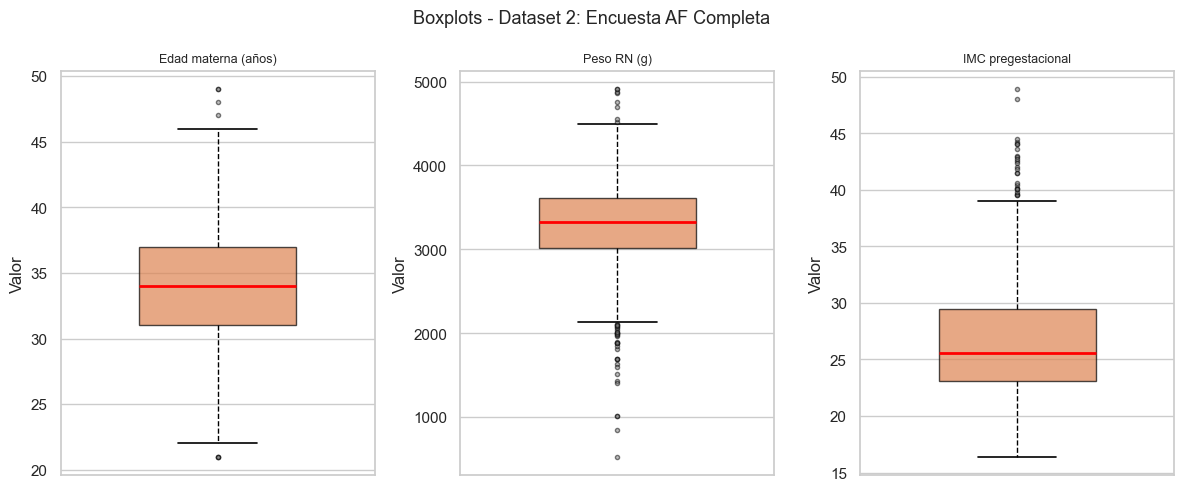

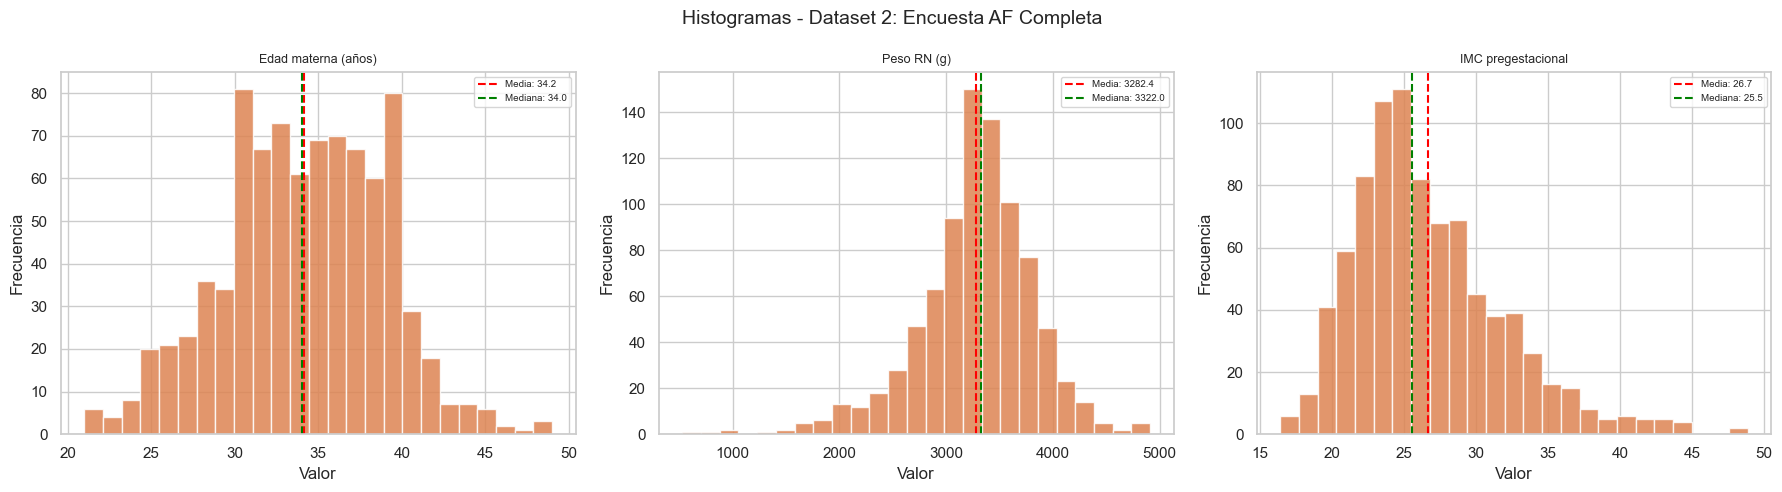

In [90]:
vars_num_d2 = ['edad_madre', 'peso_rn', 'imc_pregestacional']
vars_num_d2 = [v for v in vars_num_d2 if v in df2.columns and pd.to_numeric(df2[v], errors='coerce').notna().sum() > 5]

titulos_d2 = {
    'edad_madre': 'Edad materna (años)',
    'peso_rn': 'Peso RN (g)',
    'imc_pregestacional': 'IMC pregestacional',
}

if len(vars_num_d2) == 0:
    print('No hay variables válidas para boxplots en Dataset 2')
else:
    n = len(vars_num_d2)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, vars_num_d2):
        data = pd.to_numeric(df2[col], errors='coerce').dropna()

        ax.boxplot(
            data,
            patch_artist=True,
            widths=0.5,
            boxprops=dict(facecolor='#DD8452', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(linestyle='--'),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5)
        )
        ax.set_title(titulos_d2.get(col, col), fontsize=9)
        ax.set_xticks([])
        ax.set_ylabel('Valor')

    fig.suptitle('Boxplots - Dataset 2: Encuesta AF Completa', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'boxplots_dataset2.png'), bbox_inches='tight', dpi=100)
    plt.show()

if len(vars_num_d2) == 0:
    print('No hay variables válidas para histogramas en Dataset 2')
else:
    fig, axes = plt.subplots(1, len(vars_num_d2), figsize=(6*len(vars_num_d2), 5))
    if len(vars_num_d2) == 1:
        axes = [axes]

    for ax, col in zip(axes, vars_num_d2):
        data = pd.to_numeric(df2[col], errors='coerce').dropna()

        ax.hist(data, bins=25, color='#DD8452', edgecolor='white', alpha=0.85)
        ax.axvline(data.mean(), color='red', linestyle='--', label=f'Media: {data.mean():.1f}')
        ax.axvline(data.median(), color='green', linestyle='--', label=f'Mediana: {data.median():.1f}')
        ax.set_title(titulos_d2.get(col, col), fontsize=9)
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=7)

    fig.suptitle('Histogramas - Dataset 2: Encuesta AF Completa', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'histogramas_dataset2.png'), bbox_inches='tight', dpi=100)
    plt.show()

## 13. Análisis descriptivo de variables cualitativas

Generamos tablas de frecuencia y gráficas de barras para las variables categóricas más relevantes.

In [91]:
def tabla_frecuencias(df, col, label=None):
    # Tabla de frecuencias absolutas y relativas, incluyendo faltantes.
    serie = df[col].astype(object).where(df[col].notna(), 'No reportado')
    fa = serie.value_counts(dropna=False)
    fr = (fa / len(df) * 100).round(1)
    t  = pd.DataFrame({'Frecuencia': fa, 'Porcentaje (%)': fr})
    t.index.name = label or col
    return t


cat_d1 = [
    ('sexo',                'Sexo del ultimo hijo'),
    ('neduc',               'Nivel educacional'),
    ('region_chile',        'Region de Chile'),
    ('consumio_saf_binario','Consumio suplemento AF'),
    ('categoria_pnacer',    'Categoria peso al nacer'),
]
cat_d1 = [(c, l) for c, l in cat_d1 if c in df1.columns]

tablas_d1 = {}
for col, label in cat_d1:
    t = tabla_frecuencias(df1, col, label)
    tablas_d1[col] = t
    print(f'\n--- {label} ---')
    display(t)



--- Sexo del ultimo hijo ---


,Frecuencia,Porcentaje (%)
Sexo del ultimo hijo,,
1.00,596,50.90
2.00,521,44.50
No reportado,53,4.50



--- Nivel educacional ---


,Frecuencia,Porcentaje (%)
Nivel educacional,,
6,453,38.70
4,312,26.70
5,234,20.00
7,98,8.40
3,56,4.80
2,13,1.10
1,4,0.30



--- Region de Chile ---


,Frecuencia,Porcentaje (%)
Region de Chile,,
13,437,37.40
5,252,21.50
8,109,9.30
9,63,5.40
14,60,5.10
4,59,5.00
7,46,3.90
2,33,2.80
15,33,2.80



--- Consumio suplemento AF ---


,Frecuencia,Porcentaje (%)
Consumio suplemento AF,,
1.00,1008,86.20
0.00,162,13.80



--- Categoria peso al nacer ---


,Frecuencia,Porcentaje (%)
Categoria peso al nacer,,
Normal (2500-3999g),916,78.30
No reportado,115,9.80
Macrosomia (>=4000g),86,7.40
Bajo peso (1500-2499g),44,3.80
Muy bajo (<1500g),9,0.80


In [92]:
cat_d2 = [
    ('sexo_rn_c',          'Sexo del RN'),
    ('nivel_educacional_c', 'Nivel educacional materno'),
    ('region_c',           'Region de Chile'),
    ('primipara_c',        'Primipara'),
    ('pandemia_c',         'Periodo pandemia COVID-19'),
    ('categoria_imc',      'Categoria IMC pregestacional'),
]
cat_d2 = [(c, l) for c, l in cat_d2 if c in df2.columns]

tablas_d2 = {}
for col, label in cat_d2:
    t = tabla_frecuencias(df2, col, label)
    tablas_d2[col] = t
    print(f'\n--- {label} ---')
    display(t)



--- Sexo del RN ---


,Frecuencia,Porcentaje (%)
Sexo del RN,,
1.00,438,51.30
2.00,412,48.30
No reportado,3,0.40



--- Nivel educacional materno ---


,Frecuencia,Porcentaje (%)
Nivel educacional materno,,
4.00,516,60.50
5.00,206,24.20
3.00,75,8.80
2.00,49,5.70
1.00,4,0.50
No reportado,3,0.40



--- Region de Chile ---


,Frecuencia,Porcentaje (%)
Region de Chile,,
1.00,428,50.20
10.00,69,8.10
2.00,65,7.60
4.00,55,6.40
9.00,45,5.30
12.00,44,5.20
3.00,35,4.10
6.00,23,2.70
13.00,18,2.10



--- Primipara ---


,Frecuencia,Porcentaje (%)
Primipara,,
1.00,462,54.20
0.00,388,45.50
No reportado,3,0.40



--- Periodo pandemia COVID-19 ---


,Frecuencia,Porcentaje (%)
Periodo pandemia COVID-19,,
0.00,568,66.60
1.00,282,33.10
No reportado,3,0.40


### 13.1 Gráficas de barras — Dataset 1

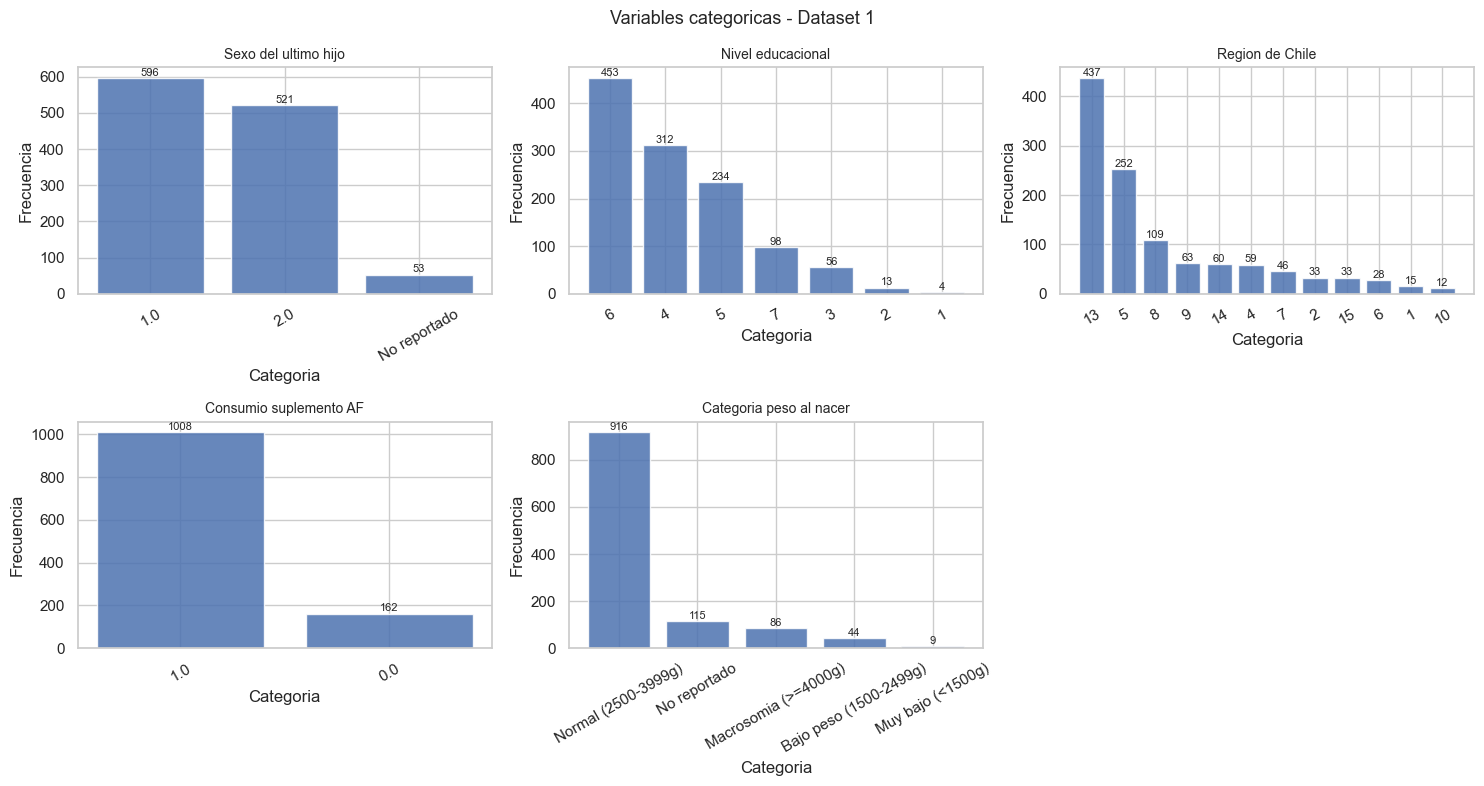

In [93]:
nc = 3
nr = (len(cat_d1) + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
axes = axes.flatten() if nr > 1 else list(axes)

for i, (col, label) in enumerate(cat_d1):
    serie = df1[col].astype(object).where(df1[col].notna(), 'No reportado')
    freq = serie.value_counts(dropna=False).head(12)
    bars = axes[i].bar(freq.index.astype(str), freq.values,
                       color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('Categoria')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)),
                     ha='center', va='bottom', fontsize=8)

for j in range(len(cat_d1), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Variables categoricas - Dataset 1', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'barras_categoricas_dataset1.png'), bbox_inches='tight', dpi=100)
plt.show()


### 13.2 Gráficas de barras — Dataset 2

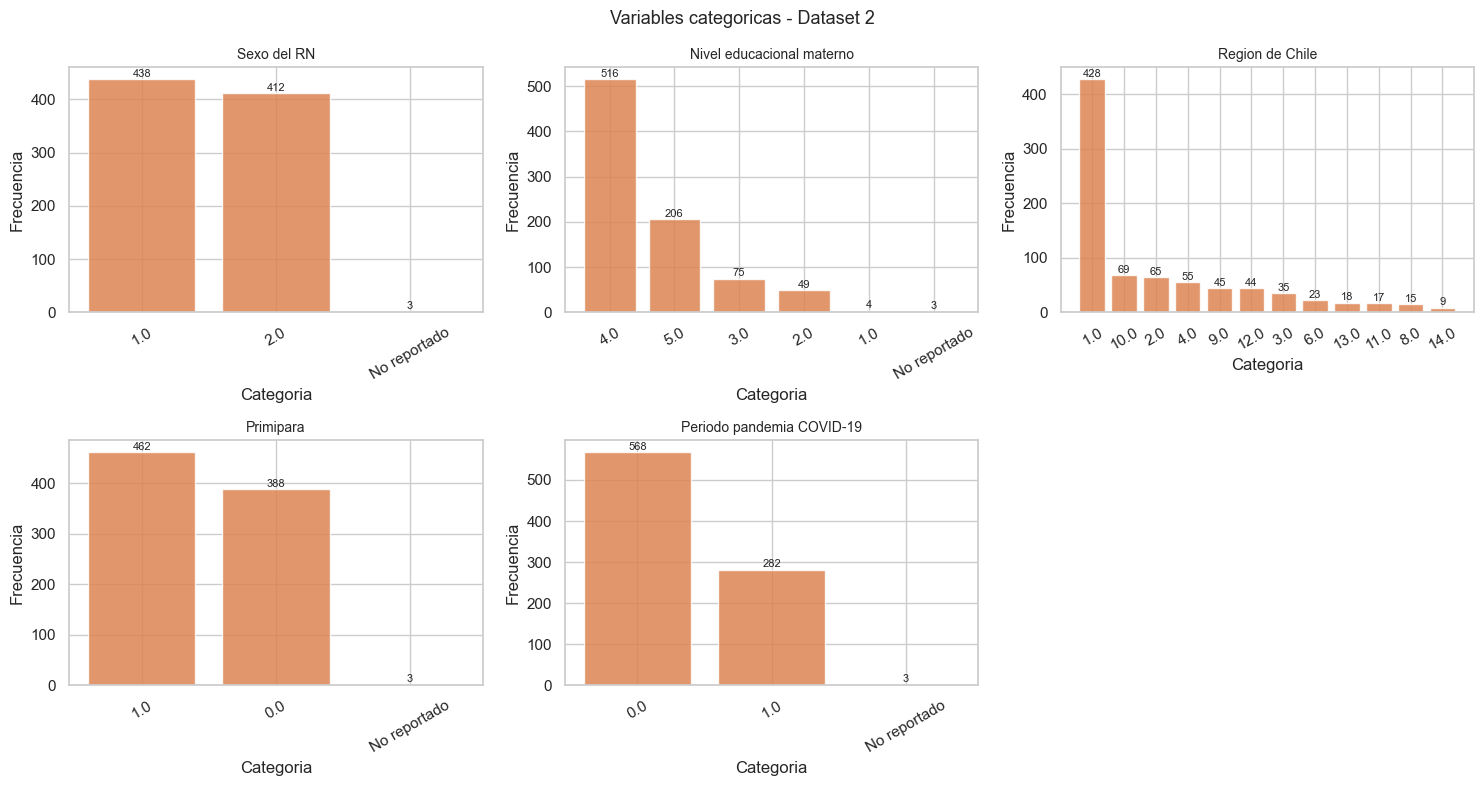

In [94]:
nc = 3
nr = (len(cat_d2) + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
axes = axes.flatten()

for i, (col, label) in enumerate(cat_d2):
    serie = df2[col].astype(object).where(df2[col].notna(), 'No reportado')
    freq = serie.value_counts(dropna=False).head(12)
    bars = axes[i].bar(freq.index.astype(str), freq.values,
                       color='#DD8452', edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('Categoria')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)),
                     ha='center', va='bottom', fontsize=8)

for j in range(len(cat_d2), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Variables categoricas - Dataset 2', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'barras_categoricas_dataset2.png'), bbox_inches='tight', dpi=100)
plt.show()


### 13.3 Gráficas de pastel — variables binarias

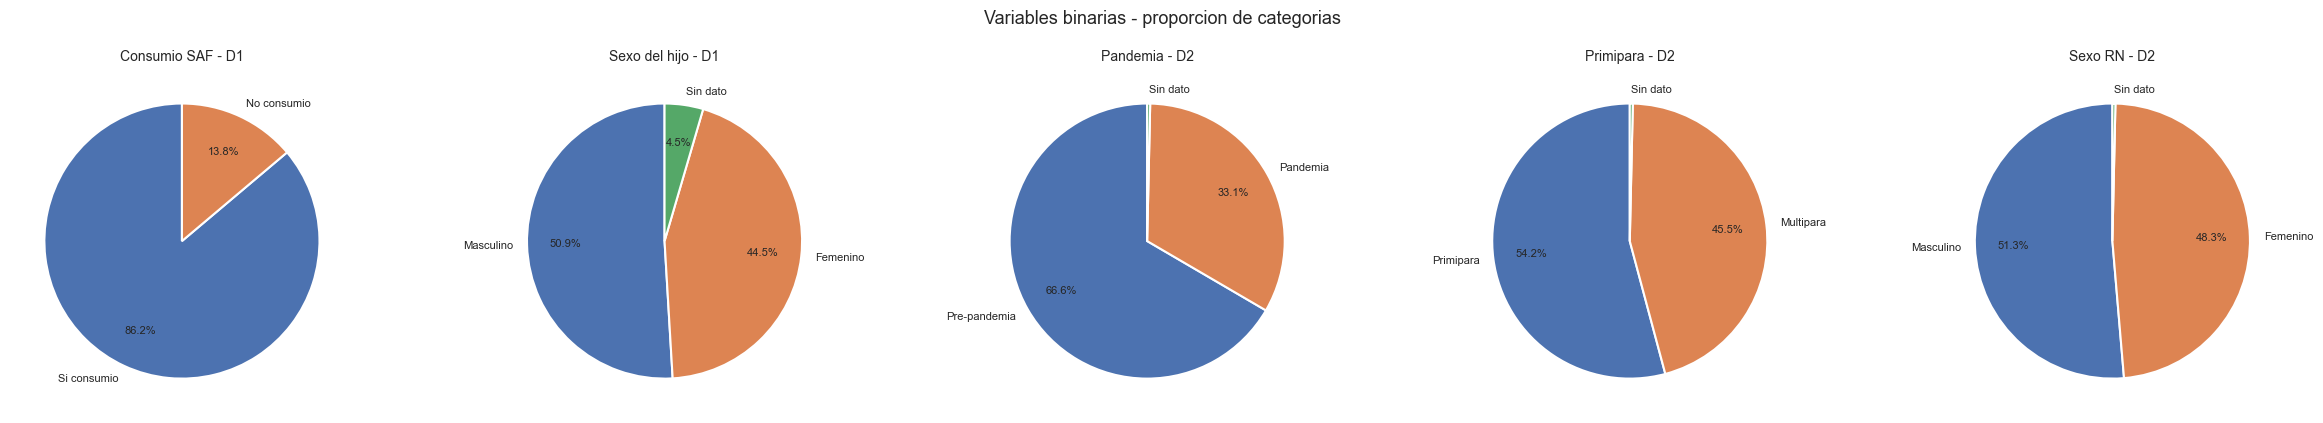

In [95]:
binarias = [
    (df1, 'consumio_saf_binario', 'Consumio SAF - D1', {0: 'No consumio', 1: 'Si consumio'}),
    (df1, 'sexo',       'Sexo del hijo - D1',  {1: 'Masculino', 2: 'Femenino'}),
    (df2, 'pandemia_c', 'Pandemia - D2',        {0: 'Pre-pandemia', 1: 'Pandemia'}),
    (df2, 'primipara_c','Primipara - D2',       {0: 'Multipara', 1: 'Primipara'}),
    (df2, 'sexo_rn_c',  'Sexo RN - D2',         {1: 'Masculino', 2: 'Femenino'}),
]
binarias = [(d, c, t, m) for d, c, t, m in binarias if c in d.columns]

fig, axes = plt.subplots(1, len(binarias), figsize=(4.8*len(binarias), 4.3))
if len(binarias) == 1:
    axes = [axes]

for ax, (df_src, col, titulo, mapa) in zip(axes, binarias):
    s = pd.to_numeric(df_src[col], errors='coerce')
    labels = s.map(mapa)
    labels = labels.where(s.isin(mapa.keys()), 'Sin dato')
    freq = labels.value_counts(dropna=False)
    if freq.empty:
        ax.set_visible(False)
        continue
    ax.pie(
        freq.values,
        labels=freq.index,
        autopct=lambda p: f'{p:.1f}%' if p >= 3 else '',
        colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(freq)],
        startangle=90,
        labeldistance=1.1,
        pctdistance=0.72,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 8}
    )
    ax.set_title(titulo, fontsize=10)

fig.suptitle('Variables binarias - proporcion de categorias', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pastel_binarias.png'), bbox_inches='tight', dpi=100)
plt.show()


In [96]:
os.makedirs(os.path.join(PROC_DIR, 'tablas_frecuencia'), exist_ok=True)
for col, t in tablas_d1.items():
    t.to_csv(os.path.join(PROC_DIR, 'tablas_frecuencia', f'd1_{col}.csv'), encoding='utf-8-sig')
for col, t in tablas_d2.items():
    t.to_csv(os.path.join(PROC_DIR, 'tablas_frecuencia', f'd2_{col}.csv'), encoding='utf-8-sig')
print('Tablas de frecuencia guardadas.')

Tablas de frecuencia guardadas.


## 14. Relaciones entre variables

Analizamos correlaciones entre variables numéricas y exploramos visualmente algunas relaciones categórica-numérica.

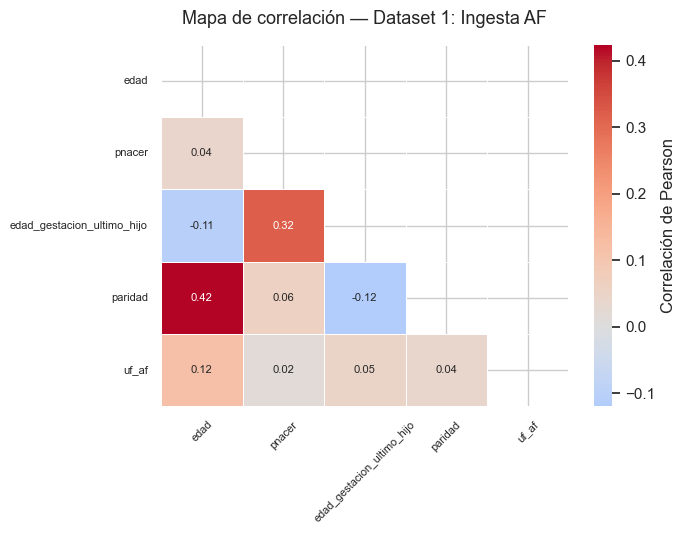

In [97]:
def mapa_correlacion(df, cols, titulo, archivo):
    df_num = df[cols].apply(lambda x: pd.to_numeric(x, errors='coerce')).dropna(how='all')
    df_num = df_num.dropna(axis=1, how='all')  # eliminar cols sin datos numéricos
    cols = list(df_num.columns)  # actualizar lista de columnas
    corr = df_num.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    n = len(cols)
    fig, ax = plt.subplots(figsize=(max(7, n*0.75), max(5.5, n*0.65)))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Correlación de Pearson'},
                annot_kws={'size': 8})
    ax.set_title(titulo, fontsize=13, pad=15)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, archivo), bbox_inches='tight', dpi=100)
    plt.show()
    return corr


cols_corr_d1 = ['edad', 'pnacer', 'edad_gestacion_ultimo_hijo', 'paridad', 'n__panes', 'uf_af']
cols_corr_d1 = [c for c in cols_corr_d1 if c in df1.columns]
corr_d1 = mapa_correlacion(df1, cols_corr_d1,
                            'Mapa de correlación — Dataset 1: Ingesta AF',
                            'correlacion_dataset1.png')

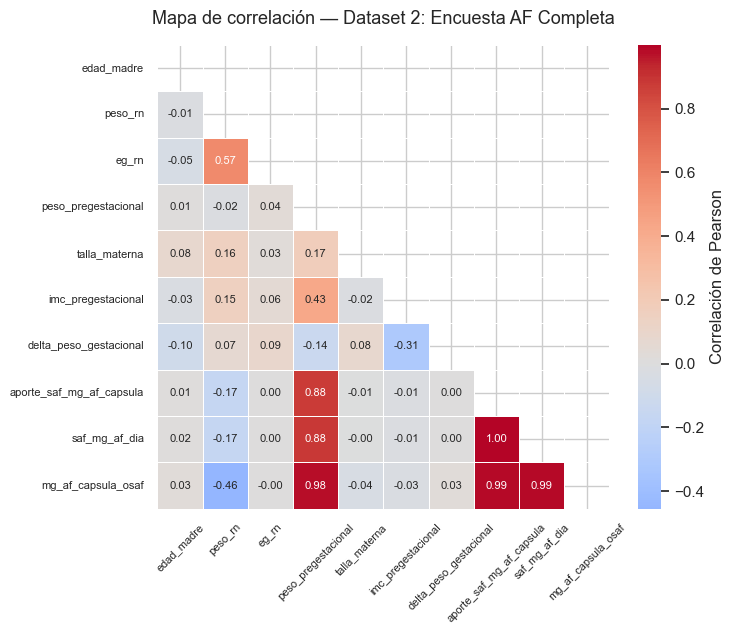

In [98]:
cols_corr_d2 = ['edad_madre', 'peso_rn', 'eg_rn', 'peso_pregestacional',
                 'talla_materna', 'imc_pregestacional', 'delta_peso_gestacional']
cols_extra = [c for c in df2.columns if 'mg_af' in c or 'saf_mg' in c][:3]
cols_corr_d2 = [c for c in cols_corr_d2 + cols_extra if c in df2.columns]
corr_d2 = mapa_correlacion(df2, cols_corr_d2,
                            'Mapa de correlación — Dataset 2: Encuesta AF Completa',
                            'correlacion_dataset2.png')

In [99]:
def correlaciones_fuertes(corr, umbral=0.3, nombre=''):
    print(f'\n=== Correlaciones |r| > {umbral} — {nombre} ===')
    cols = corr.columns
    found = False
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr.iloc[i, j]
            if abs(r) > umbral:
                dir_ = 'positiva' if r > 0 else 'negativa'
                print(f'  {cols[i]:35s} <-> {cols[j]:35s}: r = {r:.3f} ({dir_})')
                found = True
    if not found:
        print(f'  Sin correlaciones |r| > {umbral}')

correlaciones_fuertes(corr_d1, umbral=0.3, nombre='Dataset 1')
correlaciones_fuertes(corr_d2, umbral=0.3, nombre='Dataset 2')


=== Correlaciones |r| > 0.3 — Dataset 1 ===
  edad                                <-> paridad                            : r = 0.424 (positiva)
  pnacer                              <-> edad_gestacion_ultimo_hijo         : r = 0.319 (positiva)

=== Correlaciones |r| > 0.3 — Dataset 2 ===
  peso_rn                             <-> eg_rn                              : r = 0.568 (positiva)
  peso_rn                             <-> mg_af_capsula_osaf                 : r = -0.455 (negativa)
  peso_pregestacional                 <-> imc_pregestacional                 : r = 0.426 (positiva)
  peso_pregestacional                 <-> aporte_saf_mg_af_capsula           : r = 0.880 (positiva)
  peso_pregestacional                 <-> saf_mg_af_dia                      : r = 0.881 (positiva)
  peso_pregestacional                 <-> mg_af_capsula_osaf                 : r = 0.976 (positiva)
  imc_pregestacional                  <-> delta_peso_gestacional             : r = -0.306 (negativa)
  aporte

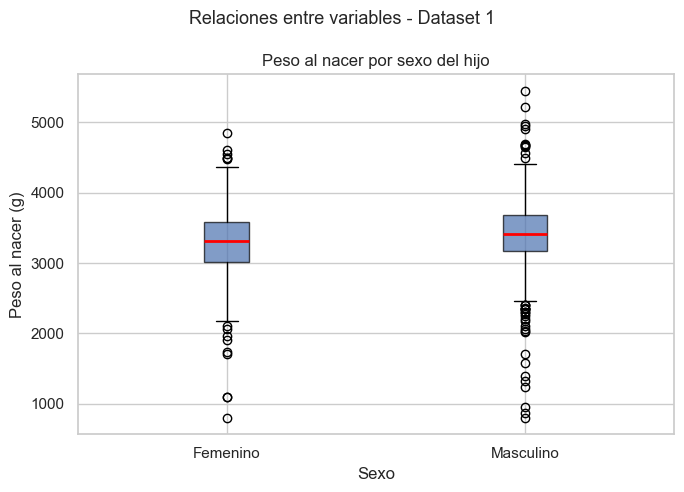

In [100]:
# Relaciones categorica-numerica - Dataset 1
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Peso al nacer por sexo (excluye categoria 0 y pesos no validos)
if 'pnacer' in df1.columns and 'sexo' in df1.columns:
    sexo_num = pd.to_numeric(df1['sexo'], errors='coerce')
    pnacer_num = pd.to_numeric(df1['pnacer'], errors='coerce')
    mask = pnacer_num.notna() & (pnacer_num > 0) & sexo_num.isin([1, 2])
    df_tmp = df1.loc[mask].copy()
    df_tmp['pnacer'] = pnacer_num.loc[mask]
    df_tmp['sexo_str'] = sexo_num.loc[mask].map({1: 'Masculino', 2: 'Femenino'})

    grupos = [g['pnacer'].values for _, g in df_tmp.groupby('sexo_str')]
    etiq = [k for k, _ in df_tmp.groupby('sexo_str')]
    if len(grupos) >= 1:
        ax.boxplot(grupos, labels=etiq, patch_artist=True,
                   boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title('Peso al nacer por sexo del hijo')
        ax.set_xlabel('Sexo')
        ax.set_ylabel('Peso al nacer (g)')
    else:
        ax.set_visible(False)

fig.suptitle('Relaciones entre variables - Dataset 1', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'relaciones_d1.png'), bbox_inches='tight', dpi=100)
plt.show()


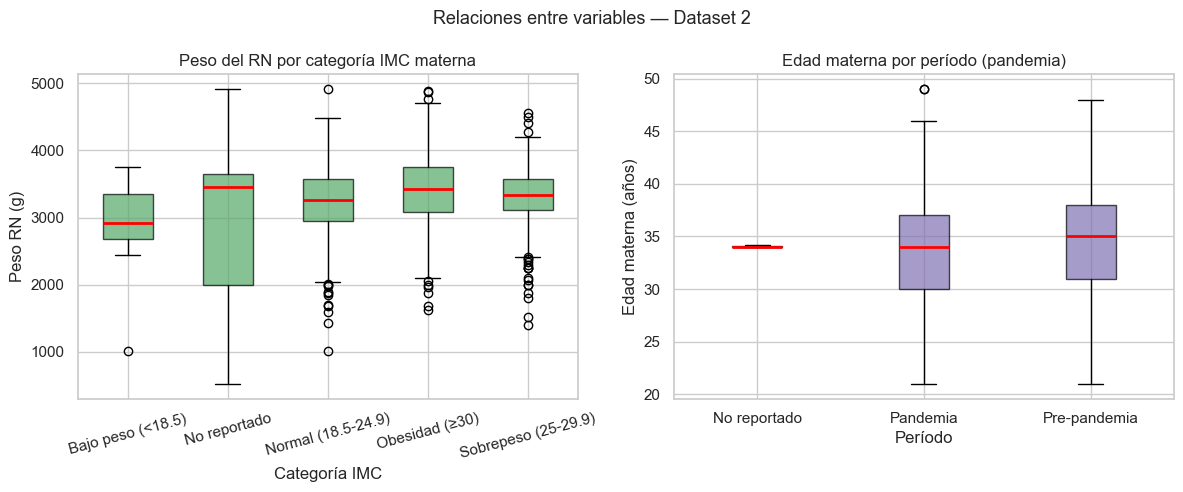

In [108]:
# Relaciones categórica–numérica — Dataset 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Peso RN por categoría IMC
if 'categoria_imc_pregestacional' in df2.columns and 'peso_rn' in df2.columns:
    df_tmp3 = df2[df2['peso_rn'].notna() & df2['categoria_imc_pregestacional'].notna()]
    grupos3 = [g['peso_rn'].values for _, g in df_tmp3.groupby('categoria_imc_pregestacional')]
    etiq3   = [k for k, _ in df_tmp3.groupby('categoria_imc_pregestacional')]

    axes[0].boxplot(
        grupos3,
        labels=etiq3,
        patch_artist=True,
        boxprops=dict(facecolor='#55A868', alpha=0.7),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[0].set_title('Peso del RN por categoría IMC materna')
    axes[0].set_xlabel('Categoría IMC')
    axes[0].set_ylabel('Peso RN (g)')
    axes[0].tick_params(axis='x', rotation=15)

# Edad materna por pandemia
if 'pandemia_label' in df2.columns and 'edad_madre' in df2.columns:
    df_tmp4 = df2[df2['edad_madre'].notna() & df2['pandemia_label'].notna()]
    grupos4 = [g['edad_madre'].values for _, g in df_tmp4.groupby('pandemia_label')]
    etiq4   = [k for k, _ in df_tmp4.groupby('pandemia_label')]
    axes[1].boxplot(grupos4, labels=etiq4, patch_artist=True,
                    boxprops=dict(facecolor='#8172B2', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('Edad materna por período (pandemia)')
    axes[1].set_xlabel('Período')
    axes[1].set_ylabel('Edad materna (años)')

fig.suptitle('Relaciones entre variables — Dataset 2', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'relaciones_d2.png'), bbox_inches='tight', dpi=100)
plt.show()



Guardamos las bases limpias y todos los archivos auxiliares generados.

In [109]:
# Dataset 1 limpio
df1.to_csv(os.path.join(PROC_DIR, 'dataset1_ingesta_af_limpio.csv'),   index=False, encoding='utf-8-sig')
df1.to_excel(os.path.join(PROC_DIR, 'dataset1_ingesta_af_limpio.xlsx'), index=False)
print(f'Dataset 1 guardado: {df1.shape}')

# Dataset 2 limpio
df2.to_csv(os.path.join(PROC_DIR, 'dataset2_encuesta_af_limpio.csv'),   index=False, encoding='utf-8-sig')
df2.to_excel(os.path.join(PROC_DIR, 'dataset2_encuesta_af_limpio.xlsx'), index=False)
print(f'Dataset 2 guardado: {df2.shape}')

# Verificación
print('\nContenido de data/processed/:')
for f in sorted(os.listdir(PROC_DIR)):
    print(f'  {f}')

print('\nFiguras generadas en outputs/:')
for f in sorted(os.listdir(OUT_DIR)):
    print(f'  {f}')

Dataset 1 guardado: (1170, 69)
Dataset 2 guardado: (853, 100)

Contenido de data/processed/:
  dataset1_ingesta_af_limpio.csv
  dataset1_ingesta_af_limpio.xlsx
  dataset2_encuesta_af_limpio.csv
  dataset2_encuesta_af_limpio.xlsx
  diccionario_dataset1_ingesta.csv
  diccionario_dataset2_encuesta.csv
  estadisticas_numericas_dataset1.csv
  estadisticas_numericas_dataset2.csv
  reporte_manejo_faltantes_d1.csv
  reporte_manejo_faltantes_d2.csv
  reporte_reglas_semanticas_d1.csv
  reporte_reglas_semanticas_d2.csv
  tablas_frecuencia

Figuras generadas en outputs/:
  barras_categoricas_dataset1.png
  barras_categoricas_dataset2.png
  barras_discretas_dataset1.png
  boxplots_dataset1.png
  boxplots_dataset2.png
  correlacion_dataset1.png
  correlacion_dataset2.png
  histogramas_dataset1.png
  histogramas_dataset2.png
  pastel_binarias.png
  pie_discretas_dataset1.png
  relaciones_d1.png
  relaciones_d2.png
  valores_faltantes.png


## 16. Conclusiones

### Archivos inspeccionados

| Archivo | Hoja utilizada | Registros | Columnas | Rol |
|---------|---------------|-----------|----------|-----|
| `1. Encuesta acido folico 1.xlsx` | Hoja1 | 84 | 4 | Codificador/diccionario — no usado como datos |
| `1. Ingesta de AF en embarazo FINAL (1) (1).xlsx` | `BD Artículo` | 1170 | 63 | **Base principal D1** |
| `2. Base Datos encuesta AF 2_mas completa 2.xlsx` | `Base Consenso` | 854 | 78 | **Base principal D2** |
| `2. Base Datos encuesta AF 2_mas completa para comparar.xlsx` | `BASE FINAL` | 705 | 66 | Referencia / comparación |

### Problemas de calidad detectados

- **Encoding**: Los archivos Excel tienen caracteres con tildes y eñes que `openpyxl` maneja correctamente en Unicode.
- **Columnas multi-respuesta**: Varias columnas en Dataset 1 son indicadores binarios (0/1) de selecciones múltiples (tipos de suplemento, tipos de pan, etc.).
- **Motivo de eliminación**: El Dataset 2 incluye esta columna para registros descartados; fue documentada y conservada para trazabilidad.
- **Valores faltantes**: Presentes principalmente en variables clínicas e ingesta cuantitativa. Se documentaron sin imputación agresiva.
- **Valores extremos**: Se detectaron y corrigieron (a NaN) valores biológicamente imposibles en edad, peso al nacer, edad gestacional e IMC.

### Limpieza realizada

1. Normalización de nombres de columnas (snake_case, sin tildes).
2. Eliminación de filas y columnas completamente vacías.
3. Conversión de columnas de fecha a `datetime`.
4. Corrección de valores biológicamente imposibles → NaN con justificación.
5. Eliminación de duplicados exactos.
6. Creación de variables derivadas: `consumio_saf_binario`, `categoria_pnacer`, `categoria_imc`, `pandemia_label`.

### Bases procesadas generadas

| Archivo | Descripción |
|---------|-------------|
| `dataset1_ingesta_af_limpio.csv/.xlsx` | Dataset 1 limpio — Ingesta AF |
| `dataset2_encuesta_af_limpio.csv/.xlsx` | Dataset 2 limpio — Encuesta AF Completa |
| `diccionario_dataset1_ingesta.csv` | Diccionario de variables D1 |
| `diccionario_dataset2_encuesta.csv` | Diccionario de variables D2 |
| `estadisticas_numericas_dataset1.csv` | Estadísticas descriptivas D1 |
| `estadisticas_numericas_dataset2.csv` | Estadísticas descriptivas D2 |
| `tablas_frecuencia/` | Tablas de frecuencia por variable categórica |



